In [1]:
!pip install --upgrade google-api-python-client google-auth-httplib2 google-auth-oauthlib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
from google.oauth2 import service_account
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
import pandas as pd
import io

# Step 1: Set credentials
SERVICE_ACCOUNT_FILE = 'C:\\Users\\naing\\MultiVacSim\\spring25research.json'
SCOPES = ['https://www.googleapis.com/auth/drive.readonly']
creds = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES
)

# Step 2: Build service
drive_service = build('drive', 'v3', credentials=creds)

# Step 3: Function to load CSV from Drive
def load_csv_from_drive(file_id):
    request = drive_service.files().get_media(fileId=file_id)
    fh = io.BytesIO()
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while not done:
        _, done = downloader.next_chunk()
    fh.seek(0)
    return pd.read_csv(fh)

# # Example: COVID hospitalization file
# df = load_csv_from_drive("1euq3iccfFdFX9ipkuX5j-r3z3PtonVBk")
# print(df.head())


In [3]:
# import gym 
# from gym import spaces
# import numpy as np
# import pandas as pd
# import random
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt
# import sys
# import os

# # ----------------------
# # Data Loader
# # ----------------------
# def normalize(series):
#     diff = series.max() - series.min()
#     if diff == 0 or series.dropna().empty:
#         return pd.Series([0] * len(series), index=series.index)
#     return (series - series.min()) / (diff + 1e-8)

# def clean_numeric_column(series):
#     return pd.to_numeric(series.astype(str).str.replace('%', '', regex=False).str.replace('>', '', regex=False), errors='coerce')

# def load_data(disease_type=None, data_level=None, geo_level=None):
#     disease_type = disease_type.upper() if disease_type else "COVID"
#     data_level = data_level.lower() if data_level else "normalized"
#     geo_level = geo_level.lower() if geo_level else "national"
#     # Validate values
#     if disease_type not in {"COVID", "FLU"}:
#         print(f"❌ Invalid disease_type: {disease_type}")
#         return None
#     if data_level not in {"raw", "normalized"}:
#         print(f"❌ Invalid level: {data_level}")
#         return None
#     if geo_level not in {"national", "regional", "state"}:
#         print(f"❌ Invalid geo_level: {geo_level}")
#         return None
    
#     # if disease_type == "COVID":
#     #     hosp_path = "C:\\Users\\naing\\MultiVacSim\\data\\covid\\weekly_covid_hospitilization.csv"
#     #     death_path = "C:\\Users\\naing\\MultiVacSim\\data\\covid\\Total_Covid_death_by_age.csv"
#     #     vaccine_path = "C:\\Users\\naing\\MultiVacSim\\data\\covid\\Main_Vaccination.csv"
#     #     for path in [hosp_path, death_path, vaccine_path]:
#     #         if not os.path.exists(path):
#     #             print(f"❌ File missing: {path}")
#     #             return None
#     #     try:
#     #         hosp = pd.read_csv(hosp_path)
#     #         deaths = pd.read_csv(death_path)
#     #         vaccine = pd.read_csv(vaccine_path)
#     # File IDs for each dataset by geo level
#     file_ids = {
#         "COVID": {
#             "national": {
#                 "hospital": "1euq3iccfFdFX9ipkuX5j-r3z3PtonVBk",
#                 "death": "1ML_bLFZvl18KjRk0X7u1bZ3j44qWxjH4",
#                 "vaccine": "1v47Sqi5dcOERvz3wHWTBGAjXLas3VmWq"
#             },
#             "regional": {
#                 "hospital": "1euq3iccfFdFX9ipkuX5j-r3z3PtonVBk",
#                 "death": "1ML_bLFZvl18KjRk0X7u1bZ3j44qWxjH4",
#                 "vaccine": "1v47Sqi5dcOERvz3wHWTBGAjXLas3VmWq"
#             },
#             "state": {
#                 "hospital": "1euq3iccfFdFX9ipkuX5j-r3z3PtonVBk",
#                 "death": "1ML_bLFZvl18KjRk0X7u1bZ3j44qWxjH4",
#                 "vaccine": "1v47Sqi5dcOERvz3wHWTBGAjXLas3VmWq"
#             },
#         },
#         "FLU": {
#             "national": {
#                 "death": "1xlwDm2jmrn5NwV45PWMIie_--TBdV8bN",
#                 "cumulative": "1cmxUyiXb-ISzel-8OAh6wiXsZ87OBhhU",
#                 "seasonal": "1PiJ5dXEirrsFELXtNE50XVkPOOJq-cqb"
#             },
#             "regional": {
#                 "death": "150cLlW4BaGyYKEFOh1mdEwIriCOu2VVk",
#                 "cumulative": "1cmxUyiXb-ISzel-8OAh6wiXsZ87OBhhU",
#                 "seasonal": "1PiJ5dXEirrsFELXtNE50XVkPOOJq-cqb",        
#             },
#             "state": {
#                 "death": "1l8Pyny1_mfXYVcBF55QYRu_oYBPDU6Gh",
#                 "cumulative": "1cmxUyiXb-ISzel-8OAh6wiXsZ87OBhhU",
#                 "seasonal": "1PiJ5dXEirrsFELXtNE50XVkPOOJq-cqb",        
#             },
#         }
#     }
#     if disease_type == "COVID":
#         ids = file_ids.get(disease_type.upper(), {}).get(geo_level, {})
#         if not ids:
#             print(f"❌ No files found for {disease_type} at {geo_level} level.")
#             return None
        
#         try:
#             hosp = load_csv_from_drive(ids["hospital"])
#             deaths = load_csv_from_drive(ids["death"])
#             vaccine = load_csv_from_drive(ids["vaccine"])
            
#             # print("[DEBUG] Vaccine columns:", vaccine.columns.tolist())

#             # Numeric vaccine features (column-wise)
#             total_doses = vaccine["Cumulative_Doses"].dropna().astype(float).sum()
#             mean_dose = vaccine["Dose"].dropna().astype(float).mean() if "Dose" in vaccine.columns else 0
#             total_population = 330_000_000
#             vaccine_supply_ratio = total_doses / total_population
#             dose_rate = mean_dose / 100_000  # scale dose

#             hosp_col = hosp.columns[-1]
#             death_col = deaths.columns[-1]
#             hosp[hosp_col] = pd.to_numeric(hosp[hosp_col], errors='coerce')
#             deaths[death_col] = pd.to_numeric(deaths[death_col], errors='coerce')
#             hosp = hosp.dropna(subset=[hosp_col])
#             deaths = deaths.dropna(subset=[death_col])

#             # Create 1-row dataframe with column-wise features
#             df = pd.DataFrame([{
#                 "hospitalization_rate": normalize(hosp[hosp_col]).mean() if data_level == "normalized" else hosp[hosp_col].mean() / 100,
#                 "death_rate": normalize(deaths[death_col]).mean() if data_level == "normalized" else deaths[death_col].mean() / 100,
#                 "vaccine_supply_ratio": vaccine_supply_ratio,
#                 "mean_weekly_dose": dose_rate
#             }])
#             return df
#         except Exception as e:
#             print(f"[ERROR loading COVID data]: {e}")
#             return None

#     elif disease_type == "FLU":
#         # hosp_path = "C:\\Users\\naing\\MultiVacSim\\data\\flu\\NHSN_Hospital_Respiratory_Data_2021-22_National.csv"
#         # death_path = "C:\\Users\\naing\\MultiVacSim\\data\\flu\\PIMS_from_the_NCMSS_National.csv"
#         # cumulative_path = "C:\\Users\\naing\\MultiVacSim\\data\\flu\\Weekly_Cumulative_Doses_in_Millions__of_Influenza_Vaccine_Distributed_by_Flu_Season_in_the_United_States.csv"
#         # seasonal_path = "C:\\Users\\naing\\MultiVacSim\\data\\flu\\Influenza Vaccine Doses Distributed in the United States, By Season.csv"

#         # for path in [hosp_path, death_path, cumulative_path, seasonal_path]:
#         #         if not os.path.exists(path):
#         #             print(f"❌ File missing: {path}")
#         #             return None
#         # try:
#         #     hosp = pd.read_csv(hosp_path)
#         #     deaths = pd.read_csv(death_path)
#         #     cumulative = pd.read_csv(cumulative_path)
#         #     seasonal = pd.read_csv(seasonal_path)
#         base_path = "C:\\Users\\naing\\MultiVacSim\\data\\flu\\processed"

#         if geo_level == "national":
#             hosp_path = os.path.join(base_path, "NHSN_National.csv")
#         elif geo_level == "regional":
#             hosp_path = os.path.join(base_path, "NHSN_HHS_Region.csv")
#         elif geo_level == "state":
#             hosp_path = os.path.join(base_path, "NHSN_State.csv")
#         ids = file_ids["FLU"].get(geo_level)
#         if not ids:
#             print(f"❌ No FLU data available for geo level: {geo_level}")
#             return None

#         try:
#             hosp = pd.read_csv(hosp_path)            
#             deaths = load_csv_from_drive(ids["death"])
#             cumulative = load_csv_from_drive(ids["cumulative"])
#             seasonal = load_csv_from_drive(ids["seasonal"])
        
#             hosp_col = hosp.columns[-1]
#             death_col = deaths.columns[-1]
#             hosp[hosp_col] = pd.to_numeric(hosp[hosp_col], errors='coerce')
#             deaths[death_col] = pd.to_numeric(deaths[death_col], errors='coerce')
#             hosp = hosp.dropna(subset=[hosp_col])
#             deaths = deaths.dropna(subset=[death_col])

#             death_rate = normalize(deaths[death_col]).mean() if data_level == "normalized" else deaths[death_col].mean() / 100
#             if pd.isna(death_rate): death_rate = 0.01  # fallback value

#             cumulative_total = pd.to_numeric(cumulative.iloc[:, -1], errors='coerce').dropna().max() * 1e6  # last cumulative value in millions
#             seasonal_avg = pd.to_numeric(seasonal.iloc[:, -1], errors='coerce').dropna().mean() * 1e6        # mean seasonal dose
#             total_population = 330_000_000
#             vaccine_supply_ratio = cumulative_total / total_population
#             mean_weekly_dose = seasonal_avg / (52 * 100_000)

#             # Create 1-row dataframe with column-wise features
#             df = pd.DataFrame([{
#                 "hospitalization_rate": normalize(hosp[hosp_col]).mean() if data_level == "normalized" else hosp[hosp_col].mean() / 100,
#                 "death_rate": normalize(deaths[death_col]).mean() if data_level == "normalized" else deaths[death_col].mean() / 100,
#                 "vaccine_supply_ratio": vaccine_supply_ratio,
#                 "mean_weekly_dose": mean_weekly_dose
#             }])
#             print("🔍 Final FLU raw national data row:")
#             print(df)
#             print("Is NaN:", df.isna().sum())
            
#             return df
#         except Exception as e:
#             print(f"[ERROR loading FLU data]: {e}")
#             return None

#     else:
#         print("❌ Only COVID or FLU are supported for data integration.")
#         return None


In [35]:
import gym 
from gym import spaces
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import sys
import os

# ----------------------
# Data Loader
# ----------------------
def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-8)

def clean_numeric_column(series):
    return pd.to_numeric(series.astype(str).str.replace('%', '', regex=False).str.replace('>', '', regex=False), errors='coerce')

# def load_data(disease_type=None, data_level=None, geo_level=None):
def load_data(disease_type=None, data_level=None, geo_level=None, start_date=None, end_date=None):
    disease_type = disease_type.upper() if disease_type else "COVID"
    data_level = data_level.lower() if data_level else "normalized"
    geo_level = geo_level.lower() if geo_level else "national"
    # Validate values
    if disease_type not in {"COVID", "FLU"}:
        print(f"❌ Invalid disease_type: {disease_type}")
        return None
    if data_level not in {"raw", "normalized"}:
        print(f"❌ Invalid level: {data_level}")
        return None
    if geo_level not in {"national", "regional", "state"}:
        print(f"❌ Invalid geo_level: {geo_level}")
        return None
    
    # if disease_type == "COVID":
    #     hosp_path = "C:\\Users\\naing\\MultiVacSim\\data\\covid\\weekly_covid_hospitilization.csv"
    #     death_path = "C:\\Users\\naing\\MultiVacSim\\data\\covid\\Total_Covid_death_by_age.csv"
    #     vaccine_path = "C:\\Users\\naing\\MultiVacSim\\data\\covid\\Main_Vaccination.csv"
    #     for path in [hosp_path, death_path, vaccine_path]:
    #         if not os.path.exists(path):
    #             print(f"❌ File missing: {path}")
    #             return None
    #     try:
    #         hosp = pd.read_csv(hosp_path)
    #         deaths = pd.read_csv(death_path)
    #         vaccine = pd.read_csv(vaccine_path)
    # File IDs for each dataset by geo level
    file_ids = {
        "COVID": {
            "national": {
                "hospital": "1euq3iccfFdFX9ipkuX5j-r3z3PtonVBk",
                "death": "1ML_bLFZvl18KjRk0X7u1bZ3j44qWxjH4",
                "vaccine": "1v47Sqi5dcOERvz3wHWTBGAjXLas3VmWq"
            },
            "regional": {
                "hospital": "1euq3iccfFdFX9ipkuX5j-r3z3PtonVBk",
                "death": "1ML_bLFZvl18KjRk0X7u1bZ3j44qWxjH4",
                "vaccine": "1v47Sqi5dcOERvz3wHWTBGAjXLas3VmWq"
            },
            "state": {
                "hospital": "1euq3iccfFdFX9ipkuX5j-r3z3PtonVBk",
                "death": "1ML_bLFZvl18KjRk0X7u1bZ3j44qWxjH4",
                "vaccine": "1v47Sqi5dcOERvz3wHWTBGAjXLas3VmWq"
            },
        },
        "FLU": {
            "national": {
                "death": "1xlwDm2jmrn5NwV45PWMIie_--TBdV8bN",
                "cumulative": "1cmxUyiXb-ISzel-8OAh6wiXsZ87OBhhU",
                "seasonal": "1PiJ5dXEirrsFELXtNE50XVkPOOJq-cqb"
            },
            "regional": {
                "death": "150cLlW4BaGyYKEFOh1mdEwIriCOu2VVk",
                "cumulative": "1cmxUyiXb-ISzel-8OAh6wiXsZ87OBhhU",
                "seasonal": "1PiJ5dXEirrsFELXtNE50XVkPOOJq-cqb",        
            },
            "state": {
                "death": "1l8Pyny1_mfXYVcBF55QYRu_oYBPDU6Gh",
                "cumulative": "1cmxUyiXb-ISzel-8OAh6wiXsZ87OBhhU",
                "seasonal": "1PiJ5dXEirrsFELXtNE50XVkPOOJq-cqb",        
            },
        }
    }
    if disease_type == "COVID":
        ids = file_ids.get(disease_type.upper(), {}).get(geo_level, {})
        if not ids:
            print(f"❌ No files found for {disease_type} at {geo_level} level.")
            return None
        
        try:
            hosp = load_csv_from_drive(ids["hospital"])
            deaths = load_csv_from_drive(ids["death"])
            vaccine = load_csv_from_drive(ids["vaccine"])
            
            # Apply time filter AFTER loading
            if start_date and end_date and 'date' in hosp.columns:
                hosp['date'] = pd.to_datetime(hosp['date'], errors='coerce')
                hosp = hosp[(hosp['date'] >= start_date) & (hosp['date'] <= end_date)]
            
            if start_date and end_date and 'date' in deaths.columns:
                deaths['date'] = pd.to_datetime(deaths['date'], errors='coerce')
                deaths = deaths[(deaths['date'] >= start_date) & (deaths['date'] <= end_date)]
            # print("[DEBUG] Vaccine columns:", vaccine.columns.tolist())

            # Numeric vaccine features (column-wise)
            total_doses = vaccine["Cumulative_Doses"].dropna().astype(float).sum()
            mean_dose = vaccine["Dose"].dropna().astype(float).mean() if "Dose" in vaccine.columns else 0
            total_population = 330_000_000
            vaccine_supply_ratio = total_doses / total_population
            dose_rate = mean_dose / 100_000  # scale dose

            hosp_col = hosp.columns[-1]
            death_col = deaths.columns[-1]
            hosp[hosp_col] = pd.to_numeric(hosp[hosp_col], errors='coerce')
            deaths[death_col] = pd.to_numeric(deaths[death_col], errors='coerce')
            hosp = hosp.dropna(subset=[hosp_col])
            deaths = deaths.dropna(subset=[death_col])

            # Create 1-row dataframe with column-wise features
            df = pd.DataFrame([{
                "hospitalization_rate": normalize(hosp[hosp_col]).mean() if data_level == "normalized" else hosp[hosp_col].mean() / 100,
                "death_rate": normalize(deaths[death_col]).mean() if data_level == "normalized" else deaths[death_col].mean() / 100,
                "vaccine_supply_ratio": vaccine_supply_ratio,
                "mean_weekly_dose": dose_rate
            }])
            return df
        except Exception as e:
            print(f"[ERROR loading COVID data]: {e}")
            return None

    elif disease_type == "FLU":
        # hosp_path = "C:\\Users\\naing\\MultiVacSim\\data\\flu\\NHSN_Hospital_Respiratory_Data_2021-22_National.csv"
        # death_path = "C:\\Users\\naing\\MultiVacSim\\data\\flu\\PIMS_from_the_NCMSS_National.csv"
        # cumulative_path = "C:\\Users\\naing\\MultiVacSim\\data\\flu\\Weekly_Cumulative_Doses_in_Millions__of_Influenza_Vaccine_Distributed_by_Flu_Season_in_the_United_States.csv"
        # seasonal_path = "C:\\Users\\naing\\MultiVacSim\\data\\flu\\Influenza Vaccine Doses Distributed in the United States, By Season.csv"

        # for path in [hosp_path, death_path, cumulative_path, seasonal_path]:
        #         if not os.path.exists(path):
        #             print(f"❌ File missing: {path}")
        #             return None
        # try:
        #     hosp = pd.read_csv(hosp_path)
        #     deaths = pd.read_csv(death_path)
        #     cumulative = pd.read_csv(cumulative_path)
        #     seasonal = pd.read_csv(seasonal_path)
        base_path = "C:\\Users\\naing\\MultiVacSim\\data\\flu\\processed"

        if geo_level == "national":
            hosp_path = os.path.join(base_path, "NHSN_National.csv")
        elif geo_level == "regional":
            hosp_path = os.path.join(base_path, "NHSN_HHS_Region.csv")
        elif geo_level == "state":
            hosp_path = os.path.join(base_path, "NHSN_State.csv")
        ids = file_ids["FLU"].get(geo_level)
        if not ids:
            print(f"❌ No FLU data available for geo level: {geo_level}")
            return None

        try:
            hosp = pd.read_csv(hosp_path)            
            deaths = load_csv_from_drive(ids["death"])
            cumulative = load_csv_from_drive(ids["cumulative"])
            seasonal = load_csv_from_drive(ids["seasonal"])

            # Apply time filter AFTER loading
            if start_date and end_date and 'date' in hosp.columns:
                hosp['date'] = pd.to_datetime(hosp['date'], errors='coerce')
                hosp = hosp[(hosp['date'] >= start_date) & (hosp['date'] <= end_date)]
            
            if start_date and end_date and 'date' in deaths.columns:
                deaths['date'] = pd.to_datetime(deaths['date'], errors='coerce')
                deaths = deaths[(deaths['date'] >= start_date) & (deaths['date'] <= end_date)]

            hosp_col = hosp.columns[-1]
            death_col = deaths.columns[-1]
            hosp[hosp_col] = pd.to_numeric(hosp[hosp_col], errors='coerce')
            deaths[death_col] = pd.to_numeric(deaths[death_col], errors='coerce')
            hosp = hosp.dropna(subset=[hosp_col])
            deaths = deaths.dropna(subset=[death_col])

            cumulative_total = pd.to_numeric(cumulative.iloc[:, -1], errors='coerce').dropna().max() * 1e6  # last cumulative value in millions
            # cumulative_total = cumulative["Cumulative_Flu_Doses"].dropna().astype(float).sum()
            seasonal_avg = pd.to_numeric(seasonal.iloc[:, -1], errors='coerce').dropna().mean() * 1e6        # mean seasonal dose
            # seasonal_avg = mean_dose = seasonal["Dose"].dropna().astype(float).mean() if "Dose" in vaccine.columns else 0
            total_population = 330_000_000
            vaccine_supply_ratio = cumulative_total / total_population
            mean_weekly_dose = seasonal_avg / (52 * 100_000)

            # Create 1-row dataframe with column-wise features
            df = pd.DataFrame([{
                "hospitalization_rate": normalize(hosp[hosp_col]).mean() if data_level == "normalized" else hosp[hosp_col].mean() / 100,
                "death_rate": normalize(deaths[death_col]).mean() if data_level == "normalized" else deaths[death_col].mean() / 100,
                "vaccine_supply_ratio": vaccine_supply_ratio,
                "mean_weekly_dose": mean_weekly_dose
            }])
            return df
        except Exception as e:
            print(f"[ERROR loading FLU data]: {e}")
            return None

    else:
        print("❌ Only COVID or FLU are supported for data integration.")
        return None


In [36]:
import gym
from gym import spaces
import numpy as np
import random


# ----------------------
# Base Environment
# ----------------------
class BaseVaccineEnv(gym.Env):
    metadata = {'render_modes': [], 'render_fps': 4}

    def __init__(self, max_steps=100, data_df=None):
        super(BaseVaccineEnv, self).__init__()
        self.max_steps = max_steps
        self.real_data = data_df
        self.state = None
        self.current_step = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = self._get_initial_state()
        self.current_step = 0
        return self.state

    def step(self, action):
        raise NotImplementedError

    def calculate_reward(self, state):
        raise NotImplementedError

    def render(self):
        pass

    def _get_initial_state(self):
        raise NotImplementedError


# ----------------------
# COVID Environment
# ----------------------
class CovidEnv(BaseVaccineEnv):
    def __init__(self, max_steps=100, data_df=None):
        super(CovidEnv, self).__init__(max_steps, data_df)
        self.state_size = 6  # Specific to COVID
        self.observation_space = spaces.Box(low=0, high=1, shape=(self.state_size,), dtype=np.float32)
        self.action_space = spaces.Discrete(6)  # Placeholder: actual COVID actions

    def _get_initial_state(self):
        state = np.zeros(self.state_size)
        if self.real_data is not None:
            row = self.real_data.iloc[0]
            state[0] = row.get("hospitalization_rate", 0.1)
            state[1] = row.get("death_rate", 0.01)
            state[2] = 0.2  # coverage
            state[3] = 0.1  # wastage
            state[4] = row.get("vaccine_supply_ratio", 0.5)
            state[5] = row.get("mean_weekly_dose", 0.01)
        else:
            state = self.observation_space.sample()
        return np.clip(state, 0, 1).astype(np.float32)

    def step(self, action):
        next_state = self.state.copy()
        coverage_idx, wastage_idx, vax_idx = 2, 3, 4
        next_state[coverage_idx] += random.uniform(0.01, 0.03) * (1 - next_state[coverage_idx])
        next_state[wastage_idx] += random.uniform(0.0, 0.01)
        reduction = next_state[vax_idx] * 0.1
        next_state[0] = max(0, next_state[0] - reduction)
        next_state[1] = max(0, next_state[1] - reduction * 0.5)
        self.state = np.clip(next_state, 0, 1).astype(np.float32)
        self.current_step += 1
        done = self.current_step >= self.max_steps
        return self.state, self.calculate_reward(self.state), done, {}

    def calculate_reward(self, state):
        hosp, death, coverage, waste = state[0], state[1], state[2], state[3]
        return -10 * hosp - 15 * death + 12 * coverage - 5 * waste


# ----------------------
# FLU Environment
# ----------------------
class FluEnv(BaseVaccineEnv):
    def __init__(self, max_steps=100, data_df=None):
        super(FluEnv, self).__init__(max_steps, data_df)
        self.state_size = 5  # [hospital, death, coverage, vaccine_ratio, dose_rate]
        self.observation_space = spaces.Box(low=0, high=1, shape=(self.state_size,), dtype=np.float32)
        self.action_space = spaces.Discrete(4)
    def _safe_value(self, val, default=0.01):
        return val if not (np.isnan(val) or val is None) else default

    def _get_initial_state(self):
        state = np.zeros(self.state_size)
        if self.real_data is not None:
            row = self.real_data.iloc[0]
            state[0] = self._safe_value(row.get("hospitalization_rate", 0.1))
            state[1] = self._safe_value(row.get("death_rate", 0.01))
            state[2] = 0.2
            state[3] = self._safe_value(row.get("vaccine_supply_ratio", 0.5))
            state[4] = self._safe_value(row.get("mean_weekly_dose", 0.01))
        else:
            state = self.observation_space.sample()
        return np.clip(state, 0, 1).astype(np.float32)

    def step(self, action):
        next_state = self.state.copy()
        next_state[2] += random.uniform(0.01, 0.02)
        next_state[0] *= 0.95  # Hospitalization drops slightly
        next_state[1] *= 0.97  # Death drops slightly
        self.state = np.clip(next_state, 0, 1).astype(np.float32)
        self.current_step += 1
        done = self.current_step >= self.max_steps
        return self.state, self.calculate_reward(self.state), done, {}

    def calculate_reward(self, state):
        if np.isnan(state[:3]).any():
            return -100  # or 0 or any fallback
        hosp, death, coverage = state[0], state[1], state[2]
        return -8 * hosp - 12 * death + 10 * coverage



# ----------------------
# MultiDiseaseEnv (Optional)
# ----------------------
class MultiDiseaseEnv(BaseVaccineEnv):
    def __init__(self, disease_type="COVID", max_steps=100, data_df=None):
        assert disease_type in {"COVID", "FLU"}, "MultiDiseaseEnv only supports 'COVID' or 'FLU'"
        self.disease_type = disease_type
        super().__init__(max_steps=max_steps, data_df=data_df)
        self.env = CovidEnv(max_steps, data_df) if disease_type == "COVID" else FluEnv(max_steps, data_df)
        self.action_space = self.env.action_space
        self.observation_space = self.env.observation_space

    def _get_initial_state(self):
        return self.env._get_initial_state()

    def step(self, action):
        return self.env.step(action)

    def calculate_reward(self, state):
        return self.env.calculate_reward(state)

    def reset(self, seed=None, options=None):
        return self.env.reset(seed=seed, options=options)


In [37]:
# ----------------------
# DQN
# ----------------------
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [57]:
# Runtime Controller
# ----------------------
if __name__ == "__main__":
    print("Select disease type: [COVID / FLU]")
    disease = input("Disease type: ").strip().upper()

    print("Select data level: [raw / normalized]")
    data_level = input("Data Level: ").strip().lower()
    
    print("Select geographic level: [national / regional / state]")
    geo_level = input("Geo level: ").strip().lower()
    # Add to prompt section
    print("Optional: Enter time frame (YYYY-MM-DD). Press Enter to skip.")
    start_date = input("Start date: ").strip() or None
    end_date = input("End date: ").strip() or None

    if disease not in {"COVID", "FLU"} or data_level not in {"raw", "normalized"} or geo_level not in {"national", "regional", "state"}:
        print("❌ Invalid input. Please enter 'COVID' or 'FLU' for disease, and 'raw' or 'normalized' for level, and 'national' or 'regional' or 'state'.")
        sys.exit(1)
    
    # Validate dates
    try:
        # Show selected time frame
        if start_date and end_date:
            print(f"\n📅 Running simulation for date range: {start_date} to {end_date}")
        elif start_date:
            print(f"\n📅 Running simulation starting from: {start_date}")
        elif end_date:
            print(f"\n📅 Running simulation up to: {end_date}")
        else:
            print("\n📅 Running simulation on full available data (no time filtering)")

    except Exception as e:
        print(f"❌ Invalid date format. Use YYYY-MM-DD. Error: {e}")
        sys.exit(1)
    # Load filtered data
    data = load_data(disease, data_level, geo_level, start_date=start_date, end_date=end_date)
    if data is None or data.empty:
        print("❌ Failed to load data. Exiting.")
        sys.exit(1)
        
    if disease == "COVID":
        env = CovidEnv(data_df=data, max_steps=50)
    elif disease == "FLU":
        env = FluEnv(data_df=data, max_steps=50)
    else:  # MULTI
        env = MultiDiseaseEnv(data_df=data, max_steps=50)
        
    state_dim = env.state_size
    action_dim = env.action_space.n
    q_network = DQN(state_dim, action_dim)
    optimizer = optim.Adam(q_network.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    num_episodes = 300
    gamma = 0.95
    epsilon = 1.0
    epsilon_min = 0.05
    epsilon_decay = 0.995

    reward_history = []
    supply_ratio_history = []
    hosp_rate_history = []
    death_rate_history = []
    for episode in range(num_episodes):
        state = env.reset()
        state = torch.tensor(state, dtype=torch.float32)
        total_reward = 0

        for _ in range(50):
            action = random.choice(range(action_dim)) if random.random() < epsilon else torch.argmax(q_network(state)).item()
            next_state, reward, done, _ = env.step(action)
            next_state = torch.tensor(next_state, dtype=torch.float32)
            target = reward + gamma * torch.max(q_network(next_state))
            prediction = q_network(state)[action]
            loss = loss_fn(prediction, target)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            state = next_state
            total_reward += reward
            if done:
                break

        reward_history.append(total_reward)
        # Capture these only at the beginning of each episode
        # Log from final state of the episode
        supply_ratio = float(state[4])  # adjust index if your env differs
        hosp_rate = float(state[0])
        death_rate = float(state[1])

        supply_ratio_history.append(supply_ratio)       # vaccine_supply_ratio
        hosp_rate_history.append(hosp_rate)             # hospitalization_rate
        death_rate_history.append(death_rate)           # death_rate

        epsilon = max(epsilon * epsilon_decay, epsilon_min)
        print(f"Episode {episode + 1}: Total Reward = {total_reward:.2f} | "
              f"Supply Ratio = {supply_ratio:.4f}, Hosp Rate = {hosp_rate:.4f}, Death Rate = {death_rate:.4f}")

Select disease type: [COVID / FLU]
Select data level: [raw / normalized]
Select geographic level: [national / regional / state]
Optional: Enter time frame (YYYY-MM-DD). Press Enter to skip.

📅 Running simulation for date range: 2021-01-01 to 2022-01-01
Episode 1: Total Reward = 146.42 | Supply Ratio = 1.0000, Hosp Rate = 0.0769, Death Rate = 0.0022
Episode 2: Total Reward = 151.68 | Supply Ratio = 1.0000, Hosp Rate = 0.0769, Death Rate = 0.0022
Episode 3: Total Reward = 142.12 | Supply Ratio = 1.0000, Hosp Rate = 0.0769, Death Rate = 0.0022
Episode 4: Total Reward = 139.79 | Supply Ratio = 1.0000, Hosp Rate = 0.0769, Death Rate = 0.0022
Episode 5: Total Reward = 138.95 | Supply Ratio = 1.0000, Hosp Rate = 0.0769, Death Rate = 0.0022
Episode 6: Total Reward = 139.54 | Supply Ratio = 1.0000, Hosp Rate = 0.0769, Death Rate = 0.0022
Episode 7: Total Reward = 145.47 | Supply Ratio = 1.0000, Hosp Rate = 0.0769, Death Rate = 0.0022
Episode 8: Total Reward = 147.42 | Supply Ratio = 1.0000, Hos

In [ ]:
supply_ratio_history = []
hosp_rate_history = []
death_rate_history = []

# Capture these only at the beginning of each episode
supply_ratio_history.append(float(state[4]))  # vaccine_supply_ratio
hosp_rate_history.append(float(state[0]))     # hospitalization_rate
death_rate_history.append(float(state[1]))    # death_rate

print("\nFinal Averages Across Episodes:")
print(f"Avg Vaccine Supply Ratio: {np.mean(supply_ratio_history):.4f}")
print(f"Avg Hospitalization Rate: {np.mean(hosp_rate_history):.4f}")
print(f"Avg Death Rate: {np.mean(death_rate_history):.4f}")



Final Averages Across Episodes:
Avg Vaccine Supply Ratio: 1.0000
Avg Hospitalization Rate: 0.0769
Avg Death Rate: 0.0022


In [66]:
# ----------------------
# Save Reward Table
# ----------------------
import pandas as pd
import os

# Create directory if it doesn't exist
output_dir = "C:\\Users\\naing\\MultiVacSim\\tables"

# Build filename using disease_type, data_level, geo_level
filename = f"{disease.lower()}_{data_level.lower()}_{geo_level.lower()}_rewards.csv"
file_path = os.path.join(output_dir, filename)

# Save to CSV
df_rewards = pd.DataFrame({
    "episode": list(range(1, len(reward_history) + 1)),
    "reward": reward_history
})
df_rewards.to_csv(file_path, index=False)
print(f"📁 Reward history saved to: {file_path}")


📁 Reward history saved to: C:\Users\naing\MultiVacSim\tables\flu_raw_national_rewards.csv


✅ Reward graph saved to: C:\Users\naing\MultiVacSim\graphs\flu\reward_plot_flu_raw_national.png


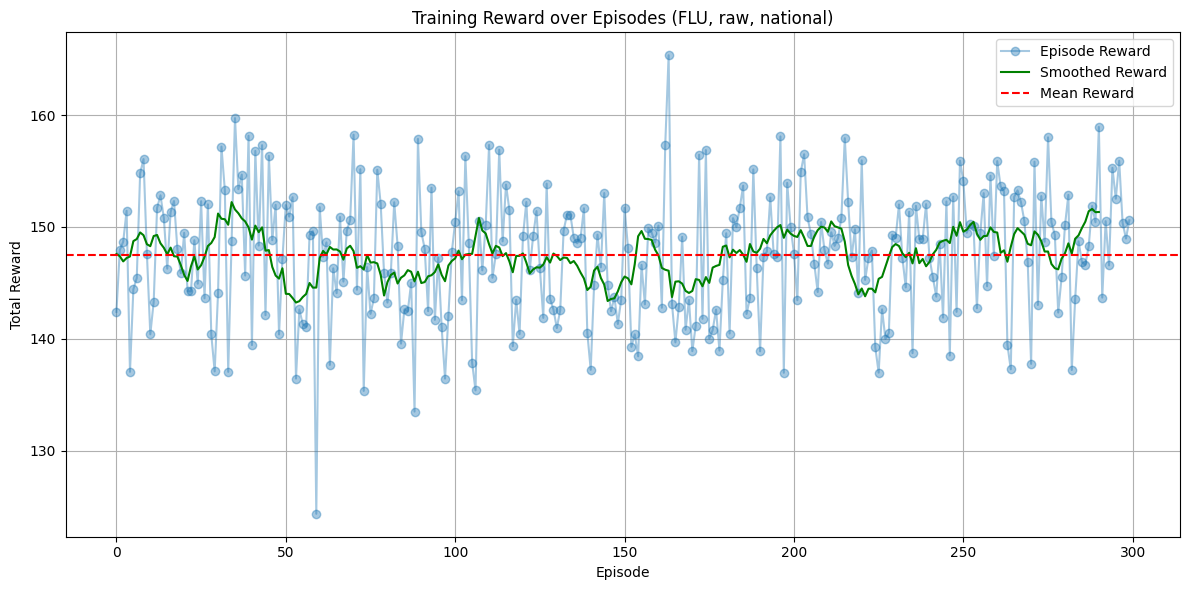

In [40]:
import os
import matplotlib.pyplot as plt
import numpy as np

# --- Function to compute moving average ---
def moving_avg(data, window_size=10):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')

# --- Graph save path ---
base_graph_dir = "C:\\Users\\naing\\MultiVacSim\\graphs"
disease_folder = os.path.join(base_graph_dir, disease.lower())  # e.g., "covid" or "flu"

# --- File name based on session settings ---
graph_filename = f"reward_plot_{disease.lower()}_{data_level.lower()}_{geo_level}.png"
graph_path = os.path.join(disease_folder, graph_filename)

# --- Plot ---
plt.figure(figsize=(12, 6))
plt.plot(reward_history, 'o-', label='Episode Reward', alpha=0.4)
if len(reward_history) >= 10:
    plt.plot(moving_avg(reward_history), label='Smoothed Reward', color='green')
plt.axhline(np.mean(reward_history), color='red', linestyle='--', label='Mean Reward')
plt.title(f"Training Reward over Episodes ({disease}, {data_level}, {geo_level})")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True)
plt.tight_layout()

# --- Save & Show ---
plt.savefig(graph_path)
print(f"✅ Reward graph saved to: {graph_path}")
plt.show()


In [41]:
import matplotlib.pyplot as plt

def plot_time_series(states, disease_type, geo_level, data_level):
    states = np.array(states)  # shape: (steps, state_dim)
    labels = ["hospitalization", "death", "coverage", "wastage", "vaccine_ratio", "dose_rate"]
    steps = range(len(states))
    
    plt.figure(figsize=(12, 6))
    for i in range(states.shape[1]):
        plt.plot(steps, states[:, i], label=labels[i])
    
    plt.title(f"{disease_type} ({geo_level}, {data_level}) - State Variables Over Time")
    plt.xlabel("Step")
    plt.ylabel("Normalized Values")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    disease_folder = os.path.join(base_graph_dir, disease.lower())  # e.g., "covid" or "flu"
    graph_filename = f"{disease.lower()}_{geo_level}_{data_level.lower()}_timeseries.png"
    output_file = os.path.join(disease_folder, graph_filename)
    
    plt.savefig(output_file)
    print(f"✅ Saved time series plot to {output_file}")
    plt.show()


✅ Saved time series plot to C:\Users\naing\MultiVacSim\graphs\flu\flu_national_raw_timeseries.png


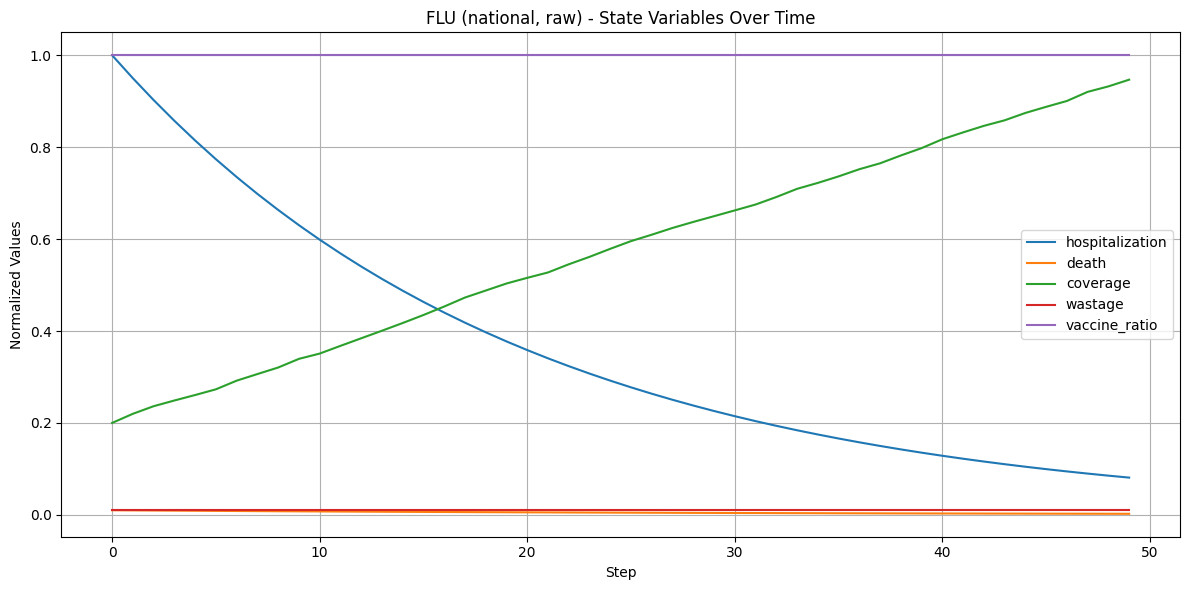

In [42]:
state_trace = []
state = env.reset()
for _ in range(50):
    state_trace.append(state)
    action = env.action_space.sample()
    state, _, done, _ = env.step(action)
    if done:
        break

plot_time_series(state_trace, disease_type=disease, geo_level=geo_level, data_level=data_level)


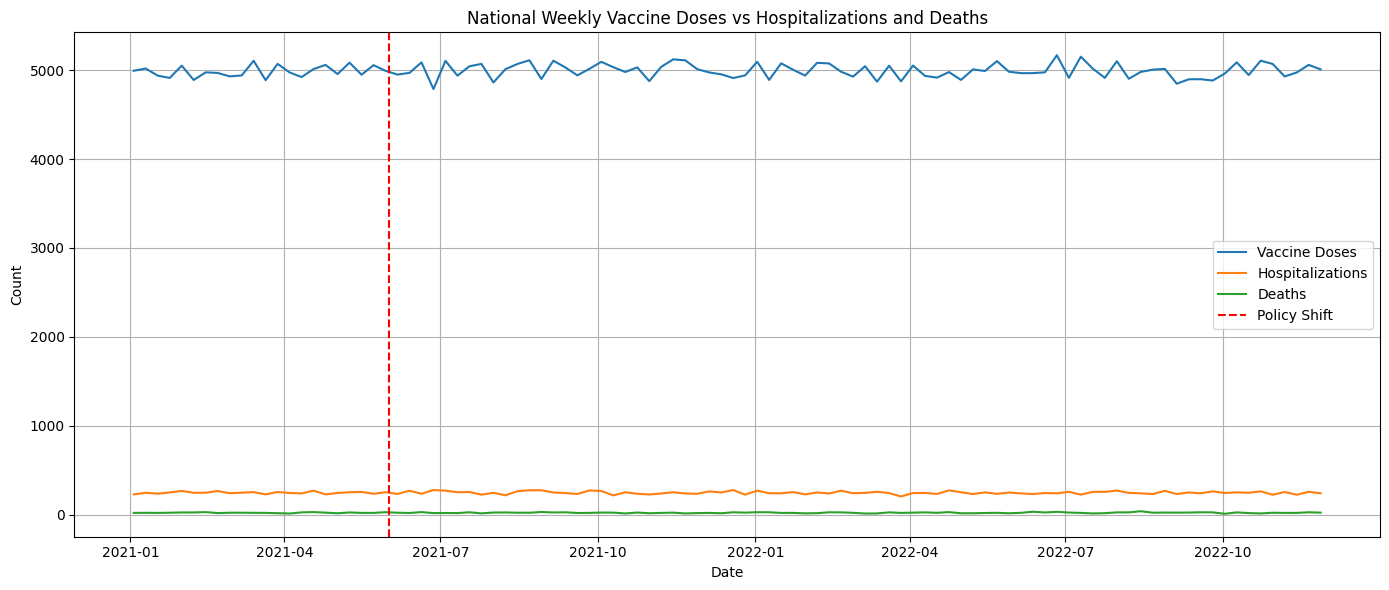

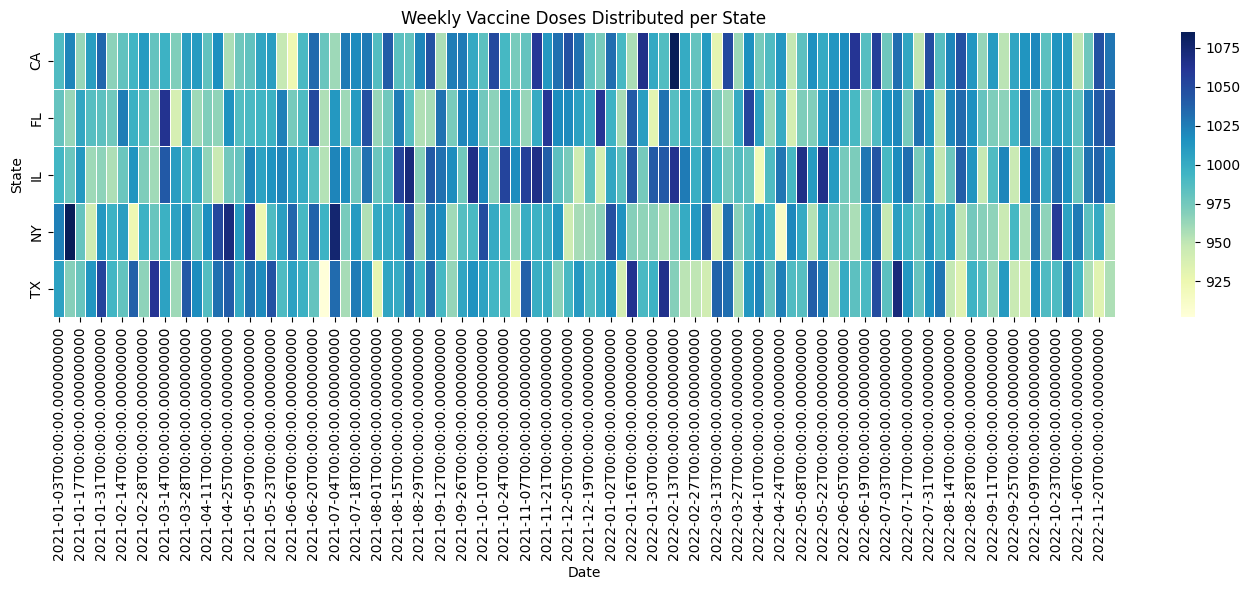

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Simulated data for demonstration
# Assume we already loaded clean CSVs for flu with date, state, doses, hospitalizations, and deaths
# Here's a sample structure we might expect
date_range = pd.date_range(start="2021-01-01", periods=100, freq='W')
states = ['CA', 'TX', 'NY', 'FL', 'IL']
np.random.seed(42)

# Time Series DataFrame
time_series_df = pd.DataFrame({
    "date": np.tile(date_range, len(states)),
    "state": np.repeat(states, len(date_range)),
    "doses": np.random.poisson(1000, len(date_range) * len(states)),
    "hospitalizations": np.random.poisson(50, len(date_range) * len(states)),
    "deaths": np.random.poisson(5, len(date_range) * len(states))
})

# 1. Time Series Plot (Aggregated Nationally)
agg_df = time_series_df.groupby("date").sum(numeric_only=True)

plt.figure(figsize=(14, 6))
plt.plot(agg_df.index, agg_df["doses"], label="Vaccine Doses")
plt.plot(agg_df.index, agg_df["hospitalizations"], label="Hospitalizations")
plt.plot(agg_df.index, agg_df["deaths"], label="Deaths")
plt.axvline(pd.to_datetime("2021-06-01"), color='red', linestyle='--', label='Policy Shift')
plt.title("National Weekly Vaccine Doses vs Hospitalizations and Deaths")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("C:/Users/naing/MultiVacSim/graphs/time_series_policy_overlay.png")
plt.show()
plt.close()

# 2. Heatmap: average dose per state across weeks
pivot_df = time_series_df.pivot_table(index="state", columns="date", values="doses", aggfunc='mean')

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_df, cmap="YlGnBu", linewidths=0.5)
plt.title("Weekly Vaccine Doses Distributed per State")
plt.xlabel("Date")
plt.ylabel("State")
plt.tight_layout()
plt.savefig("C:/Users/naing/MultiVacSim/graphs/vaccine_heatmap_by_state.png")
plt.show()
plt.close()

In [51]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -------------------------
# Load Data
# -------------------------
covid_path = "C:\\Users\\naing\\MultiVacSim\\tables\\covid_raw_national_rewards.csv"
flu_path = "C:\\Users\\naing\\MultiVacSim\\tables\\flu_raw_national_rewards.csv"

covid_df = pd.read_csv(covid_path)
flu_df = pd.read_csv(flu_path)

# Strip whitespace from column names
covid_df.columns = covid_df.columns.str.strip()
flu_df.columns = flu_df.columns.str.strip()

# Add dummy date column if missing
if "date" not in covid_df.columns:
    covid_df["date"] = pd.date_range(start="2021-01-01", periods=len(covid_df), freq="W")
if "date" not in flu_df.columns:
    flu_df["date"] = pd.date_range(start="2021-01-01", periods=len(flu_df), freq="W")

# Convert to datetime just in case
covid_df["date"] = pd.to_datetime(covid_df["date"])
flu_df["date"] = pd.to_datetime(flu_df["date"])

# -------------------------
# Output Directory
# -------------------------
graph_dir = "C:\\Users\\naing\\MultiVacSim\\graphs"
os.makedirs(graph_dir, exist_ok=True)

# -------------------------
# 1. COVID Time Series Plot
# -------------------------
covid_agg = covid_df.groupby("date").sum(numeric_only=True)
plt.figure(figsize=(14, 6))

for col in ["vaccine_supply_ratio", "hospitalization_rate", "death_rate"]:
    if col in covid_agg.columns:
        plt.plot(covid_agg.index, covid_agg[col], label=col.replace("_", " ").title())
    else:
        print(f"⚠️ Column '{col}' not found in COVID data.")

plt.axvline(pd.to_datetime("2021-06-01"), color='red', linestyle='--', label='Policy Shift')
plt.title("COVID: National Vaccine Supply vs Hospitalizations and Deaths")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(graph_dir, "covid_time_series_policy_overlay.png"))
plt.close()

# -------------------------
# 2. COVID Heatmap by State
# -------------------------
if "state" in covid_df.columns:
    covid_pivot = covid_df.pivot_table(index="state", columns="date", values="vaccine_supply_ratio", aggfunc='mean')
    plt.figure(figsize=(14, 6))
    sns.heatmap(covid_pivot, cmap="YlGnBu", linewidths=0.5)
    plt.title("COVID: Weekly Vaccine Supply Ratio per State")
    plt.xlabel("Date")
    plt.ylabel("State")
    plt.tight_layout()
    plt.savefig(os.path.join(graph_dir, "covid_vaccine_heatmap_by_state.png"))
    plt.close()
else:
    print("ℹ️ 'state' column not found in COVID data. Skipping heatmap.")

# -------------------------
# 3. FLU Time Series Plot
# -------------------------
flu_agg = flu_df.groupby("date").mean(numeric_only=True)
plt.figure(figsize=(14, 6))

for col in ["vaccine_supply_ratio", "hospitalization_rate", "death_rate"]:
    if col in flu_agg.columns:
        plt.plot(flu_agg.index, flu_agg[col], label=col.replace("_", " ").title())
    else:
        print(f"⚠️ Column '{col}' not found in FLU data.")

plt.axvline(pd.to_datetime("2021-06-01"), color='red', linestyle='--', label='Policy Shift')
plt.title("FLU: Regional Vaccine Supply vs Hospitalizations and Deaths")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(graph_dir, "flu_time_series_policy_overlay.png"))
plt.close()

# -------------------------
# 4. FLU Heatmap by Region
# -------------------------
if "region" in flu_df.columns:
    flu_pivot = flu_df.pivot_table(index="region", columns="date", values="vaccine_supply_ratio", aggfunc='mean')
    plt.figure(figsize=(14, 6))
    sns.heatmap(flu_pivot, cmap="YlGnBu", linewidths=0.5)
    plt.title("FLU: Weekly Vaccine Supply Ratio per Region")
    plt.xlabel("Date")
    plt.ylabel("Region")
    plt.tight_layout()
    plt.savefig(os.path.join(graph_dir, "flu_vaccine_heatmap_by_region.png"))
    plt.close()
else:
    print("ℹ️ 'region' column not found in FLU data. Skipping heatmap.")


⚠️ Column 'vaccine_supply_ratio' not found in COVID data.
⚠️ Column 'hospitalization_rate' not found in COVID data.
⚠️ Column 'death_rate' not found in COVID data.
ℹ️ 'state' column not found in COVID data. Skipping heatmap.
⚠️ Column 'vaccine_supply_ratio' not found in FLU data.
⚠️ Column 'hospitalization_rate' not found in FLU data.
⚠️ Column 'death_rate' not found in FLU data.
ℹ️ 'region' column not found in FLU data. Skipping heatmap.


In [14]:
def plot_time_series(df, output_path, disease="FLU"):
    agg = df.groupby("date").sum(numeric_only=True)
    plt.figure(figsize=(12, 6))
    plt.plot(agg.index, agg["doses"], label="Doses Administered")
    plt.plot(agg.index, agg["hospitalizations"], label="Hospitalizations")
    plt.plot(agg.index, agg["deaths"], label="Deaths")
    plt.axvline(pd.to_datetime("2021-06-01"), color='red', linestyle='--', label='Policy Shift')
    plt.title(f"{disease} - Weekly Trends: Doses vs Outcomes")
    plt.xlabel("Date")
    plt.ylabel("Counts")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, f"{disease.lower()}_time_series.png"))
    plt.show()
    plt.close()


In [15]:
def plot_heatmap_by_state(df, output_path, disease="FLU"):
    heatmap_data = df.pivot_table(index="state", columns="date", values="doses", aggfunc="sum")
    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_data, cmap="YlOrBr", linewidths=0.3)
    plt.title(f"{disease} - Weekly Vaccine Doses per State")
    plt.xlabel("Week")
    plt.ylabel("State")
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, f"{disease.lower()}_heatmap_states.png"))
    plt.show()
    plt.close()


Reinforcement Learning Simulation: Vaccine Strategy Environment:

This cell sets up and runs a custom OpenAI Gym environment (VaccineEnv) designed to simulate decision-making for public health vaccine strategies—either for COVID-19 or Influenza (Flu).

🧠 Environment Design: VaccineEnv
Based on disease type (COVID or FLU), different input features are used to define the agent’s environment state.

The state includes metrics such as:

Hospitalization rate

Death rate

Vaccination coverage

Wastage

Variant severity (COVID only)

Booster demand (COVID only)

Seasonality factor (Flu only)

State normalization is applied for stable training and evaluation.

Actions: The agent can choose from 6 discrete actions, which might represent different intervention or vaccination strategies.

Rewards: A simple reward function encourages higher overall health metrics, while lightly penalizing aggressive actions.

🔄 What the Simulation Does:
Loads preprocessed COVID and Flu datasets.

Initializes an environment for Flu (COVID version included but commented out).

Runs the environment for 20 time steps using random actions.

Outputs action-reward pairs at each step and prints the total reward at the end.

This provides a scaffold for training more intelligent agents in the future using reinforcement learning.

In [16]:
# import gym
# from gym import spaces
# import numpy as np
# import pandas as pd

# # Load processed data
# flu_data_path = "C:\\Users\\naing\\MultiVacSim\\data\\processed\\flu\\"
# covid_data_path = "C:\\Users\\naing\\MultiVacSim\\data\\processed\\covid\\"

# # Load datasets
# flu_dfs = {
#     "vaccination": pd.read_csv(flu_data_path + "flu_vaccination_data_s.csv"),
#     "hospitalization": pd.read_csv(flu_data_path + "flu_hospitalization_data_s.csv"),
#     "mortality": pd.read_csv(flu_data_path + "flu_mortality_data_s.csv"),
#     "trend": pd.read_csv(flu_data_path + "flu_trend_data_s.csv"),
# }
# covid_dfs = {
#     "vaccination": pd.read_csv(covid_data_path + "covid_vaccination_data_s.csv"),
#     "hospitalization": pd.read_csv(covid_data_path + "covid_hospitalization_data_s.csv"),
#     "mortality": pd.read_csv(covid_data_path + "covid_mortality_data_s.csv"),
#     "trend": pd.read_csv(covid_data_path + "covid_trend_data_s.csv"),
# }

# class VaccineEnv(gym.Env):
#     def __init__(self, disease_type="COVID", data_dict=None):
#         super(VaccineEnv, self).__init__()
#         self.disease_type = disease_type
#         self.data_dict = data_dict
#         self.pointer = 0  # Time step pointer

#         if disease_type == "COVID":
#             self.state_columns = [
#                 "hospitalization_rate", "death_rate",
#                 "vaccination_coverage", "vaccine_wastage",
#                 "variant_severity", "booster_demand",
#             ]
#         else:
#             self.state_columns = [
#                 "flu_hospitalization_rate", "flu_death_rate",
#                 "flu_vaccination_coverage", "flu_wastage",
#                 "flu_seasonality_factor"
#             ]

#         self.state_size = len(self.state_columns)
#         self.observation_space = spaces.Box(low=0, high=1, shape=(self.state_size,), dtype=np.float32)
#         self.action_space = spaces.Discrete(6)

#         # Preprocess the data to extract state values (normalize for RL)
#         self.state_data = self.prepare_state_data()

#     def prepare_state_data(self):
#         df = pd.DataFrame()
#         if self.disease_type == "COVID":
#             df["hospitalization_rate"] = self.data_dict["hospitalization"]["hospitalization_rate"].fillna(0)
#             df["death_rate"] = self.data_dict["mortality"]["death_rate"].fillna(0)
#             df["vaccination_coverage"] = self.data_dict["vaccination"]["vaccination_coverage"].fillna(0)
#             df["vaccine_wastage"] = np.random.rand(len(df)) * 0.1  # Placeholder
#             df["variant_severity"] = np.random.rand(len(df)) * 0.2
#             df["booster_demand"] = np.random.rand(len(df)) * 0.3
#         else:
#             df["flu_hospitalization_rate"] = self.data_dict["hospitalization"]["flu_hospitalization_rate"].fillna(0)
#             df["flu_death_rate"] = self.data_dict["mortality"]["flu_death_rate"].fillna(0)
#             df["flu_vaccination_coverage"] = self.data_dict["vaccination"]["vaccination_coverage"].fillna(0)
#             df["flu_wastage"] = np.random.rand(len(df)) * 0.1
#             df["flu_seasonality_factor"] = np.random.rand(len(df)) * 0.4

#         # Normalize
#         return (df - df.min()) / (df.max() - df.min() + 1e-6)

#     def get_state(self):
#         if self.pointer >= len(self.state_data):
#             self.pointer = 0  # Reset if at the end
#         state = self.state_data.iloc[self.pointer].values.astype(np.float32)
#         return state

#     def step(self, action):
#         state = self.get_state()
#         reward = self.calculate_reward(state, action)
#         self.pointer += 1
#         done = self.pointer >= len(self.state_data)
#         return state, reward, done, {}

#     def calculate_reward(self, state, action):
#         # Basic linear reward
#         return np.sum(state) - action  # reward decreases slightly with more aggressive actions

#     def reset(self):
#         self.pointer = 0
#         return self.get_state()

# # Initialize environments
# # covid_env = VaccineEnv("COVID", covid_dfs)
# flu_env = VaccineEnv("FLU", flu_dfs)

# # Simulate each environment over 20 timesteps
# def simulate(env, disease_name):
#     print(f"\n🎮 Simulating {disease_name} Vaccine Environment...")
#     state = env.reset()
#     total_reward = 0
#     for t in range(20):
#         action = env.action_space.sample()
#         next_state, reward, done, _ = env.step(action)
#         total_reward += reward
#         print(f"Timestep {t+1}: Action={action}, Reward={reward:.2f}")
#         if done:
#             break
#     print(f"✅ Total Reward for {disease_name}: {total_reward:.2f}")

# # simulate(covid_env, "COVID-19")
# simulate(flu_env, "Flu")


In [17]:
# import gym
# import pandas as pd
# from gym import spaces

# # Define the RL Environment using this synthetic population data
# class VaccineEnv(gym.Env):
#     def __init__(self, disease_type="COVID"):
#         super(VaccineEnv, self).__init__()
#         self.disease_type = disease_type

#         # Load synthetic population dataset
#         self.population_data = pd.read_csv(folder_path + "synthetic_population_data.csv")

#         # Define state space (10 for COVID, 8 for Flu)
#         self.state_size = 10 if self.disease_type == "COVID" else 8
#         self.observation_space = spaces.Box(low=0, high=1, shape=(self.state_size,), dtype=np.float32)
#         self.action_space = spaces.Discrete(6)  # Six actions: allocate, prioritize, boost supply, etc.

#     def get_state(self):
#         """Retrieve a random real-world-inspired state from synthetic data."""
#         random_state = self.population_data.sample(1).iloc[0]

#         # Convert selected region data into a state vector
#         state = np.array([
#             random_state["hospitalization_rate"],
#             random_state["death_rate"],
#             random_state["vaccine_supply"],
#             random_state["vaccine_hesitancy"],
#             random_state["booster_demand"],
#             random_state["variant_severity"] if self.disease_type == "COVID" else random_state["seasonality_factor"]
#         ], dtype=np.float32)

#         return state

#     def step(self, action):
#         state = self.get_state()
#         reward = self.calculate_reward(state, action)
#         done = False  # The environment is episodic but continuous over multiple steps
#         return state, reward, done, {}

#     def calculate_reward(self, state, action):
#         """Define reward function based on state and action."""
#         hospitalization_rate = state[0]
#         death_rate = state[1]
#         vaccination_coverage = state[2]
#         vaccine_hesitancy = state[3]
#         booster_demand = state[4]

#         if self.disease_type == "COVID":
#             variant_severity = state[5]
#             reward = (
#                 - (hospitalization_rate * 10)
#                 - (death_rate * 20)
#                 + (vaccination_coverage * 5)
#                 - (vaccine_hesitancy * 8)
#                 + (variant_severity * booster_demand * 7)
#             )
#         else:  # Flu reward function
#             seasonality_factor = state[5]
#             reward = (
#                 - (hospitalization_rate * 10)
#                 - (death_rate * 15)
#                 + (vaccination_coverage * 6)
#                 - (vaccine_hesitancy * 7)
#                 + (seasonality_factor * 5)
#             )

#         return reward

#     def reset(self):
#         """Reset the environment."""
#         return self.get_state()

# # Initialize RL Environments
# covid_env = VaccineEnv("COVID")
# flu_env = VaccineEnv("FLU")

# print("✅ RL Environment Initialized with Synthetic Data.")

Train a DQN Agent on the COVID-19 Vaccine Environment:

This section implements and trains a Deep Q-Network (DQN) agent to interact with the custom VaccineEnv using reinforcement learning. The agent learns a policy to make decisions (e.g., vaccine rollout strategies) based on public health metrics such as hospitalization, death rates, and vaccination coverage.

🧠 What’s Included:
🧱 Model Architecture (DQN class)
A simple 3-layer fully connected neural network.

Input: current environment state.

Output: estimated Q-values for each possible action.

⚙️ Training Setup
Episodes: 500 independent training runs.

Steps per episode: Limited to 50 to avoid infinite loops.

Optimizer: Adam with learning rate = 0.01.

Loss function: Mean Squared Error (MSE).

Discount factor γ: 0.95 to balance short vs. long-term reward.

Actions are currently selected randomly (can be replaced with ε-greedy later).

🔁 Training Loop
For each episode:

The environment is reset to its initial state.

The agent:

Selects a random action.

Observes the next state and reward.

Computes the target Q-value using the Bellman equation.

Trains the Q-network using backpropagation.

Total reward is recorded per episode.

This setup provides a strong baseline for more sophisticated RL strategies like ε-greedy, experience replay, or target networks.

In [18]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import random

# class DQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(DQN, self).__init__()
#         self.fc1 = nn.Linear(input_dim, 64)
#         self.fc2 = nn.Linear(64, 64)
#         self.fc3 = nn.Linear(64, output_dim)

#     def forward(self, x):
#         x = torch.relu(self.fc1(x))
#         x = torch.relu(self.fc2(x))
#         return self.fc3(x)

# # Training parameters
# num_episodes = 500
# learning_rate = 0.01
# gamma = 0.95

# # Initialize the COVID-19 RL environment
# covid_env = VaccineEnv("COVID")
# state_dim = covid_env.state_size
# action_dim = covid_env.action_space.n

# # Initialize the Q-network and optimizer
# q_network = DQN(state_dim, action_dim)
# optimizer = optim.Adam(q_network.parameters(), lr=learning_rate)
# loss_fn = nn.MSELoss()

# # Initialize a list to store rewards per episode
# reward_history = []

# # Training loop
# for episode in range(num_episodes):
#     state = covid_env.reset()
#     state = torch.tensor(state, dtype=torch.float32)

#     total_reward = 0
#     for _ in range(50):  # Limit episode length
#         action = random.choice(range(action_dim))  # Random action for now
#         next_state, reward, done, _ = covid_env.step(action)

#         next_state = torch.tensor(next_state, dtype=torch.float32)
#         reward = torch.tensor(reward, dtype=torch.float32)

#         # Q-learning update
#         target = reward + gamma * torch.max(q_network(next_state))
#         prediction = q_network(state)[action]
#         loss = loss_fn(prediction, target)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         state = next_state
#         total_reward += reward.item()

#         if done:
#             break

#     # Store reward for visualization
#     reward_history.append(total_reward)

#     print(f"Episode {episode+1}: Total Reward = {total_reward:.2f}")

# print("✅ COVID-19 RL Agent Training Complete")

Visualize COVID-19 DQN Training Performance:

This cell creates a line plot to visualize how the total reward per episode evolves during the training of the DQN agent on the COVID-19 vaccine environment.

📈 What It Shows:
X-axis: Episode number (1 to 500).

Y-axis: Total reward accumulated by the agent in each episode.

Blue Line: Episode-wise total reward (shows learning trend).

Red Dashed Line: Mean reward across all episodes (performance baseline).

This helps assess:

Whether the agent is improving over time.

Stability of the learning process.

Potential need for tuning hyperparameters or applying strategies like ε-greedy.

In [19]:
# import matplotlib.pyplot as plt
# import pandas as pd

# # Convert reward history into a DataFrame
# df = pd.DataFrame({"Episode": range(1, len(reward_history) + 1), "Reward": reward_history})

# # Plot the reward trend
# plt.figure(figsize=(10, 5))
# plt.plot(df["Episode"], df["Reward"], marker="o", linestyle="-", alpha=0.7, label="Total Reward per Episode")
# plt.axhline(y=df["Reward"].mean(), color="red", linestyle="--", label="Mean Reward")
# plt.xlabel("Episode")
# plt.ylabel("Total Reward")
# plt.title("Covid Reward Trend Over Training Episodes")
# plt.legend()
# plt.grid(True)
# plt.show()


Train a DQN Agent on the Flu Vaccine Environment:

This section adapts and trains a Deep Q-Network (DQN) agent using the same framework as the COVID-19 agent, but targets the Flu-specific version of the VaccineEnv.

🔁 What’s Different:
The environment is initialized with disease_type="FLU" which adjusts the input state to include:

flu_hospitalization_rate

flu_death_rate

flu_vaccination_coverage

flu_wastage

flu_seasonality_factor

Rewards are collected in flu_reward_history for later visualization and analysis.

⚙️ Core Setup:
Network architecture, learning rate, γ (discount factor), optimizer, and loss function are identical to the COVID training setup.

The agent performs random actions (can later be improved using ε-greedy or policy strategies).

Each episode is limited to 50 steps for efficiency.

This setup allows side-by-side evaluation and comparison between disease-specific policy learning behaviors.

In [20]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import random

# class DQN(nn.Module):
#     def __init__(self, input_dim, output_dim):
#         super(DQN, self).__init__()
#         self.fc1 = nn.Linear(input_dim, 64)
#         self.fc2 = nn.Linear(64, 64)
#         self.fc3 = nn.Linear(64, output_dim)

#     def forward(self, x):
#         x = torch.relu(self.fc1(x))
#         x = torch.relu(self.fc2(x))
#         return self.fc3(x)

# # Training parameters
# num_episodes = 500
# learning_rate = 0.01
# gamma = 0.95

# # Initialize the COVID-19 RL environment
# covid_env = VaccineEnv("FLU")
# state_dim = covid_env.state_size
# action_dim = covid_env.action_space.n

# # Initialize the Q-network and optimizer
# q_network = DQN(state_dim, action_dim)
# optimizer = optim.Adam(q_network.parameters(), lr=learning_rate)
# loss_fn = nn.MSELoss()

# # Initialize a list to store rewards per episode
# flu_reward_history = []

# # Training loop
# for episode in range(num_episodes):
#     state = covid_env.reset()
#     state = torch.tensor(state, dtype=torch.float32)

#     total_reward = 0
#     for _ in range(50):  # Limit episode length
#         action = random.choice(range(action_dim))  # Random action for now
#         next_state, reward, done, _ = covid_env.step(action)

#         next_state = torch.tensor(next_state, dtype=torch.float32)
#         reward = torch.tensor(reward, dtype=torch.float32)

#         # Q-learning update
#         target = reward + gamma * torch.max(q_network(next_state))
#         prediction = q_network(state)[action]
#         loss = loss_fn(prediction, target)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         state = next_state
#         total_reward += reward.item()

#         if done:
#             break
#     # Store reward for visualization
#     flu_reward_history.append(total_reward)

#     print(f"Episode {episode+1}: Total Reward = {total_reward:.2f}")

# print("✅ FLU RL Agent Training Complete")


Visualize Flu DQN Agent Training Performance:

This plot displays the total reward per episode during the training of the DQN agent on the Flu vaccine environment. It provides insight into how the agent's performance evolves over time.

📊 Plot Details:
X-axis: Episode number (from 1 to 500).

Y-axis: Total reward the agent received during each episode.

Line Plot: Shows how rewards change across episodes.

Red Dashed Line: Indicates the average reward across all episodes, providing a performance baseline.

Grid and markers: Improve readability and trend visibility.

This helps evaluate:

Whether the agent is learning or fluctuating randomly.

How stable or noisy the reward progression is.

If the environment or hyperparameters might need tuning.

In [21]:
# import matplotlib.pyplot as plt
# import pandas as pd

# # Convert reward history into a DataFrame
# df = pd.DataFrame({"Episode": range(1, len(reward_history) + 1), "Reward": reward_history})

# # Plot the reward trend
# plt.figure(figsize=(10, 5))
# plt.plot(df["Episode"], df["Reward"], marker="o", linestyle="-", alpha=0.7, label="Total Reward per Episode")
# plt.axhline(y=df["Reward"].mean(), color="red", linestyle="--", label="Mean Reward")
# plt.xlabel("Episode")
# plt.ylabel("Total Reward")
# plt.title("Covid Reward Trend Over Training Episodes")
# plt.legend()
# plt.grid(True)
# plt.show()


MultiVaccineEnv: Joint COVID-19 and Flu Simulation Environment:

This class defines a custom OpenAI Gym environment that integrates both the COVID-19 and Flu vaccine environments into a single, unified simulation. It enables an agent to make coordinated decisions across two disease domains, reflecting more realistic public health policy scenarios.

🧠 Key Concepts:
Sub-environments:

self.covid_env and self.flu_env are instances of VaccineEnv with "COVID" and "FLU" modes respectively.

Combined Observation Space:

The environment state is the concatenation of COVID and Flu environment states.

Each environment contributes its own health metrics (e.g., hospitalization, death rate, vaccination coverage).

Observation space dimension = covid_state_size + flu_state_size.

Combined Action Space:

There are 6 discrete actions per environment → 12 total combinations (Cartesian product).

The agent selects a joint action:

action % 6 is applied to the COVID env.

action // 6 is applied to the Flu env.

Reward:

The total reward is the sum of the COVID and Flu rewards.

Done Condition:

Episode ends if:

Hospitalization rate (state[0]) in either environment exceeds 0.3, or

Vaccination coverage (state[2]) exceeds 0.9 in both environments.

This setup encourages agents to develop joint vaccine distribution strategies that balance between managing two simultaneous disease dynamics.

In [22]:
# # Import MultiVaccineEnv
# class MultiVaccineEnv(gym.Env):
#     def __init__(self):
#         super(MultiVaccineEnv, self).__init__()
#         self.covid_env = VaccineEnv("COVID")
#         self.flu_env = VaccineEnv("FLU")

#         self.state_size = self.covid_env.state_size + self.flu_env.state_size
#         self.observation_space = gym.spaces.Box(low=0, high=1, shape=(self.state_size,), dtype=np.float32)
#         self.action_space = gym.spaces.Discrete(12)

#     def step(self, action):
#         covid_action = action % 6  
#         flu_action = action // 6  

#         covid_state, covid_reward, _, _ = self.covid_env.step(covid_action)
#         flu_state, flu_reward, _, _ = self.flu_env.step(flu_action)

#         combined_state = np.concatenate([covid_state, flu_state])
#         combined_reward = covid_reward + flu_reward  

#         done = (covid_state[0] > 0.3 or flu_state[0] > 0.3) or \
#                (covid_state[2] > 0.9 and flu_state[2] > 0.9)

#         return combined_state, combined_reward, done, {}

#     def reset(self):
#         covid_state = self.covid_env.reset()
#         flu_state = self.flu_env.reset()
#         return np.concatenate([covid_state, flu_state])

Test the MultiVaccineEnv with Random Actions:

This cell runs a basic simulation loop using the MultiVaccineEnv, which combines both COVID-19 and Flu vaccine environments. The goal is to test the environment’s behavior and observe how it responds to randomly selected joint actions.

🔁 What This Code Does:
Initializes the MultiVaccineEnv environment.

Resets the environment to get the initial joint state.

Loops for 10 steps:

Randomly samples a joint action from the combined 12-action space.

Executes the action and receives the next state, reward, and done flag.

Prints the new combined state and reward after each step.

Terminates early if the environment's done condition is triggered.

This simulation is useful for:

Verifying that the environment behaves as expected.

Ensuring the action/reward mechanics work before training an agent.

Getting a feel for state transitions and dynamics across both diseases.

In [23]:
# # Initialize the Multi-Vaccine RL Agent
# multi_vaccine_env = MultiVaccineEnv()

# state = multi_vaccine_env.reset()  # Reset environment and get initial state 

# for _ in range(10):  # Run for 10 steps
#     action = multi_vaccine_env.action_space.sample()  # Take a random action
#     next_state, reward, done, _ = multi_vaccine_env.step(action)
#     print(f"State: {next_state}, Reward: {reward}")

#     if done:
#         break  # Stop if the environment ends


Simulate Random Policy on MultiVaccineEnv and Visualize Reward Progression:

This cell runs a simple baseline simulation using a random policy to interact with the MultiVaccineEnv, which combines both COVID-19 and Flu vaccine environments. It tracks how the total reward evolves across episodes, providing a benchmark before applying reinforcement learning agents.

🔁 Simulation Workflow:
Episodes: 500 full episodes of interaction.

Steps per Episode: Limited to 50 to prevent long or infinite episodes.

Action Strategy: Randomly sample from the 12 discrete joint actions.

Reward Accumulation:

Total reward is calculated per episode.

Progress is printed every 50 episodes.

Reward Trend Visualization:

A line plot shows how total reward changes over time.

Useful for evaluating randomness vs. potential learning performance.

This simulation provides a baseline reward distribution which can later be compared to a trained RL agent’s performance.

In [24]:
# import matplotlib.pyplot as plt

# # Track rewards over episodes
# num_episodes = 500
# reward_history = []

# for episode in range(num_episodes):
#     state = multi_vaccine_env.reset()
#     total_reward = 0

#     for _ in range(50):  # Limit steps per episode (adjust as needed)
#         action = multi_vaccine_env.action_space.sample()  # Take a random action
#         next_state, reward, done, _ = multi_vaccine_env.step(action)
#         total_reward += reward  # Accumulate reward

#         if done:
#             break  # Stop if episode ends

#     reward_history.append(total_reward)  # Store reward

#     # Print progress every 50 episodes
#     if episode % 50 == 0:
#         print(f"Episode {episode}: Total Reward = {total_reward:.2f}")

# # Plot reward progression
# plt.plot(reward_history, label="Total Reward per Episode")
# plt.xlabel("Episode")
# plt.ylabel("Total Reward")
# plt.title("Reward Progression Over Training")
# plt.legend()
# plt.show()


Visualize Action Distribution in MultiVaccineEnv (Random Policy):

This cell creates a bar chart showing the distribution of actions sampled over 100 steps in the MultiVaccineEnv. It helps assess whether all actions in the discrete joint action space (0–11) are being explored equally under a random policy.

🎯 Why This Matters:
Ensures the environment’s action space is being properly sampled.

Useful for debugging the random policy before implementing ε-greedy or trained agents.

Helps interpret how actions are mapped across both COVID and Flu sub-environments.

🧪 How It Works:
Runs the environment for 100 steps, taking a random action at each step.

Collects each sampled action into a list.

Converts that list into a Pandas DataFrame for easy plotting.

Uses Seaborn’s countplot to visualize how often each action was selected.

In [25]:
# import seaborn as sns 
# import pandas as pd
# import matplotlib.pyplot as plt

# action_counts = []

# for _ in range(100):  # Run 100 steps
#     action = multi_vaccine_env.action_space.sample()  # Sample action
#     action_counts.append(action)  # Directly append the integer action

# # Convert to DataFrame for plotting
# action_df = pd.DataFrame({"Action": action_counts})

# # ✅ Visualize action distribution
# sns.countplot(data=action_df, x="Action")
# plt.xlabel("Action Taken")
# plt.ylabel("Count")
# plt.title("COVID Vaccine Action Distribution")
# plt.show()


Dynamic Visualization: COVID-19 Vaccine Coverage & Routing Optimization (U.S. States Network):

This cell creates a geographic simulation of COVID-19 vaccine distribution across all U.S. states. The network graph updates dynamically over several steps to reflect changing coverage and optimized distribution routes.

🌍 What This Simulation Shows:
U.S. states represented as nodes on a map, positioned based on approximate latitude and longitude.

Node color intensity reflects each state’s current vaccine coverage (from the environment).

Edges represent optimized vaccine distribution routes:

Based on minimum spanning tree (MST).

Enhanced with shortest paths from vaccine hubs (California, Texas, New York).

The graph updates over multiple time steps, simulating real-time dynamics of distribution efforts.

In [26]:
# import networkx as nx
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np
# import random
# import time

# env = MultiVaccineEnv()

# # ✅ Adjust positions: Keep Alaska & Hawaii fixed, center and spread the lower 48
# scale_factor = 3  # Scaling factor for visualization
# center_shift = (-98, 39)  # Rough center of the continental US to shift states

# state_coords = {}
# raw_coords = {
#     'Alabama': (32.8, -86.8), 'Alaska': (61.3, -152.4), 'Arizona': (33.7, -111.4),
#     'Arkansas': (34.9, -92.3), 'California': (36.1, -119.6), 'Colorado': (39.0, -105.3),
#     'Connecticut': (41.5, -72.7), 'Delaware': (39.3, -75.5), 'Florida': (27.7, -81.6),
#     'Georgia': (33.0, -83.6), 'Hawaii': (21.09, -157.49), 'Idaho': (44.2, -114.4),
#     'Illinois': (40.3, -88.9), 'Indiana': (39.8, -86.2), 'Iowa': (42.0, -93.2),
#     'Kansas': (38.5, -96.7), 'Kentucky': (37.6, -84.6), 'Louisiana': (31.1, -91.8),
#     'Maine': (44.6, -69.3), 'Maryland': (39.0, -76.8), 'Massachusetts': (42.2, -71.5),
#     'Michigan': (43.3, -84.5), 'Minnesota': (45.6, -93.9), 'Mississippi': (32.7, -89.6),
#     'Missouri': (38.4, -92.2), 'Montana': (46.9, -110.4), 'Nebraska': (41.1, -98.2),
#     'Nevada': (38.3, -117.0), 'New Hampshire': (43.4, -71.5), 'New Jersey': (40.2, -74.5),
#     'New Mexico': (34.8, -106.2), 'New York': (42.1, -74.9), 'North Carolina': (35.6, -79.8),
#     'North Dakota': (47.5, -99.7), 'Ohio': (40.3, -82.7), 'Oklahoma': (35.5, -96.9),
#     'Oregon': (44.5, -122.0), 'Pennsylvania': (40.5, -77.2), 'Rhode Island': (41.6, -71.5),
#     'South Carolina': (33.8, -80.9), 'South Dakota': (44.2, -99.4), 'Tennessee': (35.7, -86.6),
#     'Texas': (31.0, -97.5), 'Utah': (40.1, -111.8), 'Vermont': (44.0, -72.7),
#     'Virginia': (37.7, -78.1), 'Washington': (47.4, -121.4), 'West Virginia': (38.4, -80.9),
#     'Wisconsin': (44.2, -89.6), 'Wyoming': (42.7, -107.3)
# }

# for state, (lat, lon) in raw_coords.items():
#     if state in ['Alaska', 'Hawaii']:
#         state_coords[state] = (lon, lat)  # Keep original positions
#     else:
#         state_coords[state] = ((lon - center_shift[0]) * scale_factor, (lat - center_shift[1]) * scale_factor)

# # ✅ Create a Fully Connected Graph
# G_covid = nx.complete_graph(state_coords.keys())

# # ✅ Special connections for Alaska and Hawaii
# G_covid.add_edges_from([
#     ("Alaska", "Washington"), ("Alaska", "California"),
#     ("Hawaii", "California"), ("Hawaii", "Texas")
# ])

# # ✅ Function to update vaccine coverage dynamically
# def update_vaccine_coverage():
#     return {state: env.step(random.randint(0, 11))[0][2] for state in G_covid.nodes()}

# # ✅ Function to compute MST and Dijkstra's paths
# def compute_optimized_routes():
#     for u, v in G_covid.edges():
#         weight = 1 / (0.1 + (state_covid_coverage[u] + state_covid_coverage[v]) / 2)
#         G_covid[u][v]['weight'] = weight

#     mst = nx.minimum_spanning_tree(G_covid, weight='weight')

#     vaccine_hubs = ["California", "Texas", "New York"]
#     optimal_routes = set(mst.edges())
#     for hub in vaccine_hubs:
#         shortest_paths = nx.single_source_dijkstra_path(G_covid, hub, weight='weight')
#         for target in shortest_paths:
#             path = shortest_paths[target]
#             for i in range(len(path) - 1):
#                 optimal_routes.add((path[i], path[i+1]))

#     return optimal_routes

# # ✅ Visualization loop
# for step in range(5):
#     plt.figure(figsize=(12, 8))
    
#     state_covid_coverage = update_vaccine_coverage()
#     optimal_routes = compute_optimized_routes()

#     pos = {state: (coords[0], coords[1]) for state, coords in state_coords.items()}

#     node_colors = [state_covid_coverage[state] for state in G_covid.nodes()]
#     nodes = nx.draw_networkx_nodes(G_covid, pos, node_color=node_colors, cmap="Blues", node_size=800)
#     nx.draw_networkx_edges(G_covid, pos, edgelist=optimal_routes, edge_color="red", width=2, alpha=0.8)
    
#     state_labels = {state: f"{state}\n{state_covid_coverage[state]:.2f}" for state in G_covid.nodes()}
#     nx.draw_networkx_labels(G_covid, pos, labels=state_labels, font_size=8, font_color="black")

#     cbar = plt.colorbar(nodes)
#     cbar.set_label("Vaccine Coverage")

#     plt.title(f"Dynamic COVID-19 Vaccine Distribution - Step {step + 1}")
#     plt.xlabel("Longitude (Scaled)")
#     plt.ylabel("Latitude (Scaled)")
#     plt.grid(True)
#     plt.show()

#     df_covid = pd.DataFrame(state_covid_coverage.items(), columns=["State", "COVID Vaccine Coverage"])
#     print(f"\nCOVID Vaccine Coverage Table - Step {step + 1}\n")
#     print(df_covid.to_string(index=False))

#     time.sleep(1)


Simulated U.S. State Vaccine Coverage Over Time (Geographic Network Graph):

This section visualizes vaccine coverage levels across all U.S. states using a geographic network graph that updates dynamically over time. It provides a spatial perspective of vaccine rollout patterns and neighboring relationships between states.



In [27]:
# import pandas as pd
# import networkx as nx
# import matplotlib.pyplot as plt
# import random
# import time

# env = MultiVaccineEnv()
# # Define state coordinates (longitude, latitude) and apply scaling to spread out states
# scale_factor = 3  # Adjust this value to spread states apart
# state_coords = {
#     state: (lat * scale_factor, lon * scale_factor)  # Scale latitude and longitude
#     for state, (lat, lon) in {
#         'Alabaama': (32.806671, -86.791130), 'Alaska': (61.370716, -152.404419), 'Arizona': (33.729759, -111.431221),
#         'Arkansas': (34.969704, -92.373123), 'California': (36.116203, -119.681564), 'Colorado': (39.059811, -105.311104),
#         'Connecticut': (41.597782, -72.755371), 'Delaware': (39.318523, -75.507141), 'Florida': (27.766279, -81.686783),
#         'Georgia': (33.040619, -83.643074), 'Hawaii': (21.094318, -157.498337), 'Idaho': (44.240459, -114.478828),
#         'Illinois': (40.349457, -88.986137), 'Indiana': (39.849426, -86.258278), 'Iowa': (42.011539, -93.210526),
#         'Kansas': (38.526600, -96.726486), 'Kentucky': (37.668140, -84.670067), 'Louisiana': (31.169546, -91.867805),
#         'Maine': (44.693947, -69.381927), 'Maryland': (39.063946, -76.802101), 'Massachusetts': (42.230171, -71.530106),
#         'Michigan': (43.326618, -84.536095), 'Minnesota': (45.694454, -93.900192), 'Mississippi': (32.741646, -89.678696),
#         'Missouri': (38.456085, -92.288368), 'Montana': (46.921925, -110.454353), 'Nebraska': (41.125370, -98.268082),
#         'Nevada': (38.313515, -117.055374), 'New Hampshire': (43.452492, -71.563896), 'New Jersey': (40.298904, -74.521011),
#         'New Mexico': (34.840515, -106.248482), 'New York': (42.165726, -74.948051), 'North Carolina': (35.630066, -79.806419),
#         'North Dakota': (47.528912, -99.784012), 'Ohio': (40.388783, -82.764915), 'Oklahoma': (35.565342, -96.928917),
#         'Oregon': (44.572021, -122.070938), 'Pennsylvania': (40.590752, -77.209755), 'Rhode Island': (41.680893, -71.511780),
#         'South Carolina': (33.856892, -80.945007), 'South Dakota': (44.299782, -99.438828), 'Tennessee': (35.747845, -86.692345),
#         'Texas': (31.054487, -97.563461), 'Utah': (40.150032, -111.862434), 'Vermont': (44.045876, -72.710686),
#         'Virginia': (37.769337, -78.169968), 'Washington': (47.400902, -121.490494), 'West Virginia': (38.491226, -80.954456),
#         'Wisconsin': (44.268543, -89.616508), 'Wyoming': (42.755966, -107.302490)
#     }.items()
# }

# # Define neighboring states as edges
# state_edges = [
#     ("Alabama", "Georgia"), ("Alabama", "Tennessee"), ("Alabama", "Mississippi"),
#     ("Arizona", "California"), ("Arizona", "Nevada"), ("Arizona", "New Mexico"),
#     ("California", "Oregon"), ("California", "Nevada"), ("Colorado", "Utah"),
#     ("Colorado", "Kansas"), ("Colorado", "Nebraska"), ("Colorado", "Wyoming"),
#     ("Florida", "Georgia"), ("Florida", "Alabama"), ("Georgia", "South Carolina"),
#     ("Idaho", "Montana"), ("Idaho", "Washington"), ("Illinois", "Indiana"),
#     ("Illinois", "Iowa"), ("Illinois", "Missouri"), ("Indiana", "Ohio"),
#     ("Iowa", "Nebraska"), ("Kansas", "Missouri"), ("Kentucky", "Ohio"),
#     ("Louisiana", "Mississippi"), ("Maine", "New Hampshire"), ("Maryland", "Pennsylvania"),
#     ("Massachusetts", "Rhode Island"), ("Michigan", "Wisconsin"), ("Minnesota", "Wisconsin"),
#     ("Missouri", "Nebraska"), ("Montana", "North Dakota"), ("New Mexico", "Texas"),
#     ("New York", "New Jersey"), ("North Carolina", "South Carolina"), ("Ohio", "West Virginia"),
#     ("Oklahoma", "Texas"), ("Oregon", "Washington"), ("Tennessee", "Kentucky"),
#     ("Virginia", "West Virginia"), ("Wyoming", "South Dakota"), ("South Dakota", "North Dakota"),
#     ("North Dakota", "Minnesota"), ("Wisconsin", "Illinois"), ("Nevada", "Utah")
# ]

# # Create a graph
# G = nx.Graph()
# for state, (lat, lon) in state_coords.items():
#     G.add_node(state, pos=(lon, lat))
# G.add_edges_from(state_edges)

# # Initialize vaccine coverage (randomized)
# state_vaccine_coverage = {state: round(random.uniform(0.1, 1.0), 2) for state in G.nodes()}

# # Function to update vaccine coverage dynamically
# def update_vaccine_coverage(state_vaccine_coverage):
#     for state in state_vaccine_coverage:
#         change = random.uniform(-0.02, 0.05)  # Allow coverage to increase/decrease slightly
#         # state_vaccine_coverage[state] = round(max(0, min(1, state_vaccine_coverage[state] + change)), 2)  # Keep in [0,1]
        
#     return state_vaccine_coverage

# # Visualization loop (run multiple frames to show updates over time)
# for step in range(5):  # Number of time steps
#     plt.figure(figsize=(14, 10))  # Increase figure size for better visibility
    
#     # Update vaccine coverage
#     state_vaccine_coverage = update_vaccine_coverage(state_vaccine_coverage)

#     # Get node colors based on updated vaccine coverage
#     node_colors = [state_vaccine_coverage[state] for state in G.nodes()]
    
#     # Get positions
#     pos = nx.get_node_attributes(G, 'pos')

#     # Draw the graph
#     nodes = nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=plt.cm.viridis, node_size=1000)
#     edges = nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.5)

#     # Create labels with state names and vaccine coverage below
#     state_labels = {state: f"{state}\n{state_vaccine_coverage[state]:.2f}" for state in G.nodes()}
    
#     # Adjust label position to avoid overlap
#     label_pos = {state: (coords[0], coords[1] + 2) for state, coords in pos.items()}
    
#     # Draw labels (state names and coverage below)
#     nx.draw_networkx_labels(G, label_pos, labels=state_labels, font_size=8, font_color="black", font_weight="bold")

#     # Add colorbar
#     cbar = plt.colorbar(nodes)
#     cbar.set_label("Vaccine Coverage")

#     plt.title(f"U.S. States Vaccine Coverage (Time Step {step + 1})")
#     plt.xlabel("Longitude (Scaled)")
#     plt.ylabel("Latitude (Scaled)")
#     plt.grid(True)
#     plt.show()
    
#     # Create a DataFrame that matches the current vaccine coverage values
#     df = pd.DataFrame(list(state_vaccine_coverage.items()), columns=["State", "Vaccine Coverage"])
#     df = df.sort_values(by="State")  # Sort for consistency
#     print(f"\nVaccine Coverage Table (Time Step {step + 1})\n")
#     print(df.to_string(index=False))

#     time.sleep(1)  # Pause before next update

U.S. COVID-19 Vaccine Distribution Optimization with Network Routing:

This cell runs a national-scale simulation that models how COVID-19 vaccine coverage evolves and optimizes distribution routes across all U.S. states over time using graph theory and geographic visualization.

🗺️ What It Models:
U.S. States as Nodes: Each state is mapped geographically using scaled latitude/longitude coordinates.

Fully Connected Network: All states are initially connected to each other (as if all distribution routes were possible).

Special Routes: Direct "air/sea" routes are added from Alaska and Hawaii to mainland hubs (California, Texas, Washington).

Dynamic Simulation: Vaccine coverage is updated at every time step using the environment’s internal logic (MultiVaccineEnv).

In [28]:
# # Re-import necessary libraries after execution state reset
# import networkx as nx
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np
# import random

# # Initialize the MultiVaccine Environment
# env = MultiVaccineEnv()

# # Scale factor for visibility (Alaska & Hawaii fixed)
# scale_factor = 3  # Adjust this value to spread states apart
# state_coords = {
#     state: (lat * scale_factor, lon * scale_factor)  # Scale latitude and longitude
#     for state, (lat, lon) in {
#         'Alabama': (32.806671, -86.791130), 'Alaska': (61.370716, -152.404419), 'Arizona': (33.729759, -111.431221),
#         'Arkansas': (34.969704, -92.373123), 'California': (36.116203, -119.681564), 'Colorado': (39.059811, -105.311104),
#         'Connecticut': (41.597782, -72.755371), 'Delaware': (39.318523, -75.507141), 'Florida': (27.766279, -81.686783),
#         'Georgia': (33.040619, -83.643074), 'Hawaii': (21.094318, -157.498337), 'Idaho': (44.240459, -114.478828),
#         'Illinois': (40.349457, -88.986137), 'Indiana': (39.849426, -86.258278), 'Iowa': (42.011539, -93.210526),
#         'Kansas': (38.526600, -96.726486), 'Kentucky': (37.668140, -84.670067), 'Louisiana': (31.169546, -91.867805),
#         'Maine': (44.693947, -69.381927), 'Maryland': (39.063946, -76.802101), 'Massachusetts': (42.230171, -71.530106),
#         'Michigan': (43.326618, -84.536095), 'Minnesota': (45.694454, -93.900192), 'Mississippi': (32.741646, -89.678696),
#         'Missouri': (38.456085, -92.288368), 'Montana': (46.921925, -110.454353), 'Nebraska': (41.125370, -98.268082),
#         'Nevada': (38.313515, -117.055374), 'New Hampshire': (43.452492, -71.563896), 'New Jersey': (40.298904, -74.521011),
#         'New Mexico': (34.840515, -106.248482), 'New York': (42.165726, -74.948051), 'North Carolina': (35.630066, -79.806419),
#         'North Dakota': (47.528912, -99.784012), 'Ohio': (40.388783, -82.764915), 'Oklahoma': (35.565342, -96.928917),
#         'Oregon': (44.572021, -122.070938), 'Pennsylvania': (40.590752, -77.209755), 'Rhode Island': (41.680893, -71.511780),
#         'South Carolina': (33.856892, -80.945007), 'South Dakota': (44.299782, -99.438828), 'Tennessee': (35.747845, -86.692345),
#         'Texas': (31.054487, -97.563461), 'Utah': (40.150032, -111.862434), 'Vermont': (44.045876, -72.710686),
#         'Virginia': (37.769337, -78.169968), 'Washington': (47.400902, -121.490494), 'West Virginia': (38.491226, -80.954456),
#         'Wisconsin': (44.268543, -89.616508), 'Wyoming': (42.755966, -107.302490)
#     }.items()
# }

# # Create a Fully Connected Graph
# G_covid = nx.complete_graph(state_coords.keys())

# # Special connections for Alaska and Hawaii (Air & Boat routes)
# G_covid.add_edges_from([
#     ("Alaska", "Washington"), ("Alaska", "California"),  
#     ("Hawaii", "California"), ("Hawaii", "Texas")        
# ])

# # Function to update vaccine coverage dynamically
# def update_vaccine_coverage():
#     return {state: env.step(random.randint(0, 11))[0][2] for state in G_covid.nodes()}

# # Function to compute MST and Dijkstra's paths
# def compute_optimized_routes():
#     # Compute new weights (inverse vaccine coverage)
#     for u, v in G_covid.edges():
#         weight = 1 / (0.1 + (state_covid_coverage[u] + state_covid_coverage[v]) / 2)
#         G_covid[u][v]['weight'] = weight

#     # Compute MST (minimum required routes)
#     mst = nx.minimum_spanning_tree(G_covid, weight='weight')

#     # Compute Dijkstra's shortest paths from major vaccine hubs
#     vaccine_hubs = ["California", "Texas", "New York"]
#     optimal_routes = set(mst.edges())
#     for hub in vaccine_hubs:
#         shortest_paths = nx.single_source_dijkstra_path(G_covid, hub, weight='weight')
#         for target in shortest_paths:
#             path = shortest_paths[target]
#             for i in range(len(path) - 1):
#                 optimal_routes.add((path[i], path[i+1]))

#     return optimal_routes

# # Run the simulation until optimal routes remain
# best_results = []
# max_steps = 1000

# for step in range(max_steps):
#     # Update vaccine coverage dynamically
#     state_covid_coverage = update_vaccine_coverage()

#     # Compute optimal routes (MST + Dijkstra)
#     optimal_routes = compute_optimized_routes()

#     # Store the best 4 intermediate results
#     if step in [1, 3, 5, 7] or step == max_steps - 1:
#         best_results.append((step, optimal_routes.copy(), state_covid_coverage.copy()))

# # Display the best 4 results + final result
# for step, optimal_routes, state_covid_coverage in best_results:
#     plt.figure(figsize=(12, 8))
    
#     # Get positions
#     pos = {state: (coords[1], coords[0]) for state, coords in state_coords.items()}

#     # Draw the graph
#     node_colors = [state_covid_coverage[state] for state in G_covid.nodes()]
#     nodes = nx.draw_networkx_nodes(G_covid, pos, node_color=node_colors, cmap="Blues", node_size=800)
    
#     # Draw only optimal routes
#     nx.draw_networkx_edges(G_covid, pos, edgelist=optimal_routes, edge_color="red", width=2, alpha=0.8)
    
#     # Labels with vaccine coverage
#     state_labels = {state: f"{state}\n{state_covid_coverage[state]:.2f}" for state in G_covid.nodes()}
#     nx.draw_networkx_labels(G_covid, pos, labels=state_labels, font_size=8, font_color="black")

#     # Color bar
#     cbar = plt.colorbar(nodes)
#     cbar.set_label("Vaccine Coverage")

#     plt.title(f"Optimized COVID-19 Vaccine Distribution - Step {step + 1}")
#     plt.xlabel("Longitude (Scaled)")
#     plt.ylabel("Latitude (Scaled)")
#     plt.grid(True)
#     plt.show()

#     # Display Coverage Table
#     df_covid = pd.DataFrame(state_covid_coverage.items(), columns=["State", "COVID Vaccine Coverage"])
#     display(df_covid)


Optimized Flu Vaccine Distribution Across U.S. States Using Network Routing:

This cell simulates national-level flu vaccine distribution and coverage dynamics using a fully connected graph of U.S. states. The network graph updates based on flu vaccine coverage levels, and uses minimum spanning trees (MSTs) and Dijkstra's algorithm to identify the most efficient distribution routes over time.

🧩 What It Models:
Nodes: U.S. states, each assigned a simulated flu vaccine coverage value.

Edges: Represent potential distribution routes between states.

Special Links: Direct connections are added for Alaska and Hawaii to mainland hubs.



In [29]:
# # Initialize the MultiVaccine Environment
# env = MultiVaccineEnv()

# # Scale factor for visibility (Alaska & Hawaii fixed)
# scale_factor = 3  # Adjust this value to spread states apart
# state_coords = {
#     state: (lat * scale_factor, lon * scale_factor)  # Scale latitude and longitude
#     for state, (lat, lon) in {
#         'Alabama': (32.806671, -86.791130), 'Alaska': (61.370716, -152.404419), 'Arizona': (33.729759, -111.431221),
#         'Arkansas': (34.969704, -92.373123), 'California': (36.116203, -119.681564), 'Colorado': (39.059811, -105.311104),
#         'Connecticut': (41.597782, -72.755371), 'Delaware': (39.318523, -75.507141), 'Florida': (27.766279, -81.686783),
#         'Georgia': (33.040619, -83.643074), 'Hawaii': (21.094318, -157.498337), 'Idaho': (44.240459, -114.478828),
#         'Illinois': (40.349457, -88.986137), 'Indiana': (39.849426, -86.258278), 'Iowa': (42.011539, -93.210526),
#         'Kansas': (38.526600, -96.726486), 'Kentucky': (37.668140, -84.670067), 'Louisiana': (31.169546, -91.867805),
#         'Maine': (44.693947, -69.381927), 'Maryland': (39.063946, -76.802101), 'Massachusetts': (42.230171, -71.530106),
#         'Michigan': (43.326618, -84.536095), 'Minnesota': (45.694454, -93.900192), 'Mississippi': (32.741646, -89.678696),
#         'Missouri': (38.456085, -92.288368), 'Montana': (46.921925, -110.454353), 'Nebraska': (41.125370, -98.268082),
#         'Nevada': (38.313515, -117.055374), 'New Hampshire': (43.452492, -71.563896), 'New Jersey': (40.298904, -74.521011),
#         'New Mexico': (34.840515, -106.248482), 'New York': (42.165726, -74.948051), 'North Carolina': (35.630066, -79.806419),
#         'North Dakota': (47.528912, -99.784012), 'Ohio': (40.388783, -82.764915), 'Oklahoma': (35.565342, -96.928917),
#         'Oregon': (44.572021, -122.070938), 'Pennsylvania': (40.590752, -77.209755), 'Rhode Island': (41.680893, -71.511780),
#         'South Carolina': (33.856892, -80.945007), 'South Dakota': (44.299782, -99.438828), 'Tennessee': (35.747845, -86.692345),
#         'Texas': (31.054487, -97.563461), 'Utah': (40.150032, -111.862434), 'Vermont': (44.045876, -72.710686),
#         'Virginia': (37.769337, -78.169968), 'Washington': (47.400902, -121.490494), 'West Virginia': (38.491226, -80.954456),
#         'Wisconsin': (44.268543, -89.616508), 'Wyoming': (42.755966, -107.302490)
#     }.items()
# }

# # Create a Fully Connected Graph for Flu Vaccine
# G_flu = nx.complete_graph(state_coords.keys())

# # Special connections for Alaska and Hawaii (Air & Boat routes)
# G_flu.add_edges_from([
#     ("Alaska", "Washington"), ("Alaska", "California"),  
#     ("Hawaii", "California"), ("Hawaii", "Texas")        
# ])

# # Function to update flu vaccine coverage dynamically
# def update_vaccine_coverage():
#     return {state: env.step(random.randint(0, 11))[0][5] for state in G_flu.nodes()}  # Flu vaccine index

# # Function to compute MST and Dijkstra's paths
# def compute_optimized_routes():
#     for u, v in G_flu.edges():
#         weight = 1 / (0.1 + (state_flu_coverage[u] + state_flu_coverage[v]) / 2)
#         G_flu[u][v]['weight'] = weight

#     # Compute MST (minimum required routes)
#     mst = nx.minimum_spanning_tree(G_flu, weight='weight')
    
#     # Compute Dijkstra's shortest paths from major vaccine hubs
#     vaccine_hubs = ["California", "Texas", "New York"]
#     optimal_routes = set(mst.edges())
#     for hub in vaccine_hubs:
#         shortest_paths = nx.single_source_dijkstra_path(G_flu, hub, weight='weight')
#         for target in shortest_paths:
#             path = shortest_paths[target]
#             for i in range(len(path) - 1):
#                 optimal_routes.add((path[i], path[i+1]))
    
#     return optimal_routes

# # Run the simulation until optimal routes remain
# best_results = []
# max_steps = 1000

# for step in range(max_steps):
#     state_flu_coverage = update_vaccine_coverage()
#     optimal_routes = compute_optimized_routes()
    
#     if step in [1, 3, 5, 7] or step == max_steps - 1:
#         best_results.append((step, optimal_routes.copy(), state_flu_coverage.copy()))

# # Display the best 4 results + final result
# for step, optimal_routes, state_flu_coverage in best_results:
#     plt.figure(figsize=(12, 8))
    
#     pos = {state: (coords[1], coords[0]) for state, coords in state_coords.items()}
#     node_colors = [state_flu_coverage[state] for state in G_flu.nodes()]
#     nodes = nx.draw_networkx_nodes(G_flu, pos, node_color=node_colors, cmap="Greens", node_size=800)
    
#     nx.draw_networkx_edges(G_flu, pos, edgelist=optimal_routes, edge_color="red", width=2, alpha=0.8)
    
#     state_labels = {state: f"{state}\n{state_flu_coverage[state]:.2f}" for state in G_flu.nodes()}
#     nx.draw_networkx_labels(G_flu, pos, labels=state_labels, font_size=8, font_color="black")
    
#     cbar = plt.colorbar(nodes)
#     cbar.set_label("Flu Vaccine Coverage")
#     plt.title(f"Optimized Flu Vaccine Distribution - Step {step + 1}")
#     plt.xlabel("Longitude (Scaled)")
#     plt.ylabel("Latitude (Scaled)")
#     plt.grid(True)
#     plt.show()
    
#     df_flu = pd.DataFrame(state_flu_coverage.items(), columns=["State", "Flu Vaccine Coverage"])
#     display(df_flu)
